In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

print("✅ Environnement prêt.")

✅ Environnement prêt.


In [2]:
employes          = pd.read_csv("employes.csv")
transactions      = pd.read_csv("transactions.csv")
logs_acces        = pd.read_csv("logs_acces.csv",      parse_dates=["timestamp"])
interrogatoires   = pd.read_csv("interrogatoires.csv")
emails            = pd.read_csv("emails.csv",           parse_dates=["timestamp"])
preuves           = pd.read_csv("preuves_materielles.csv")

fichiers = {
    "employes":        employes,
    "transactions":    transactions,
    "logs_acces":      logs_acces,
    "interrogatoires": interrogatoires,
    "emails":          emails,
    "preuves":         preuves,
}

for nom, df in fichiers.items():
    print(f"📂 {nom:20s} → {df.shape[0]:>5} lignes × {df.shape[1]:>2} colonnes")

📂 employes             →    10 lignes × 12 colonnes
📂 transactions         →  2500 lignes × 11 colonnes
📂 logs_acces           → 10649 lignes ×  4 colonnes
📂 interrogatoires      →   300 lignes ×  6 colonnes
📂 emails               →  1005 lignes ×  6 colonnes
📂 preuves              →    10 lignes ×  7 colonnes


# Profils RH des suspects

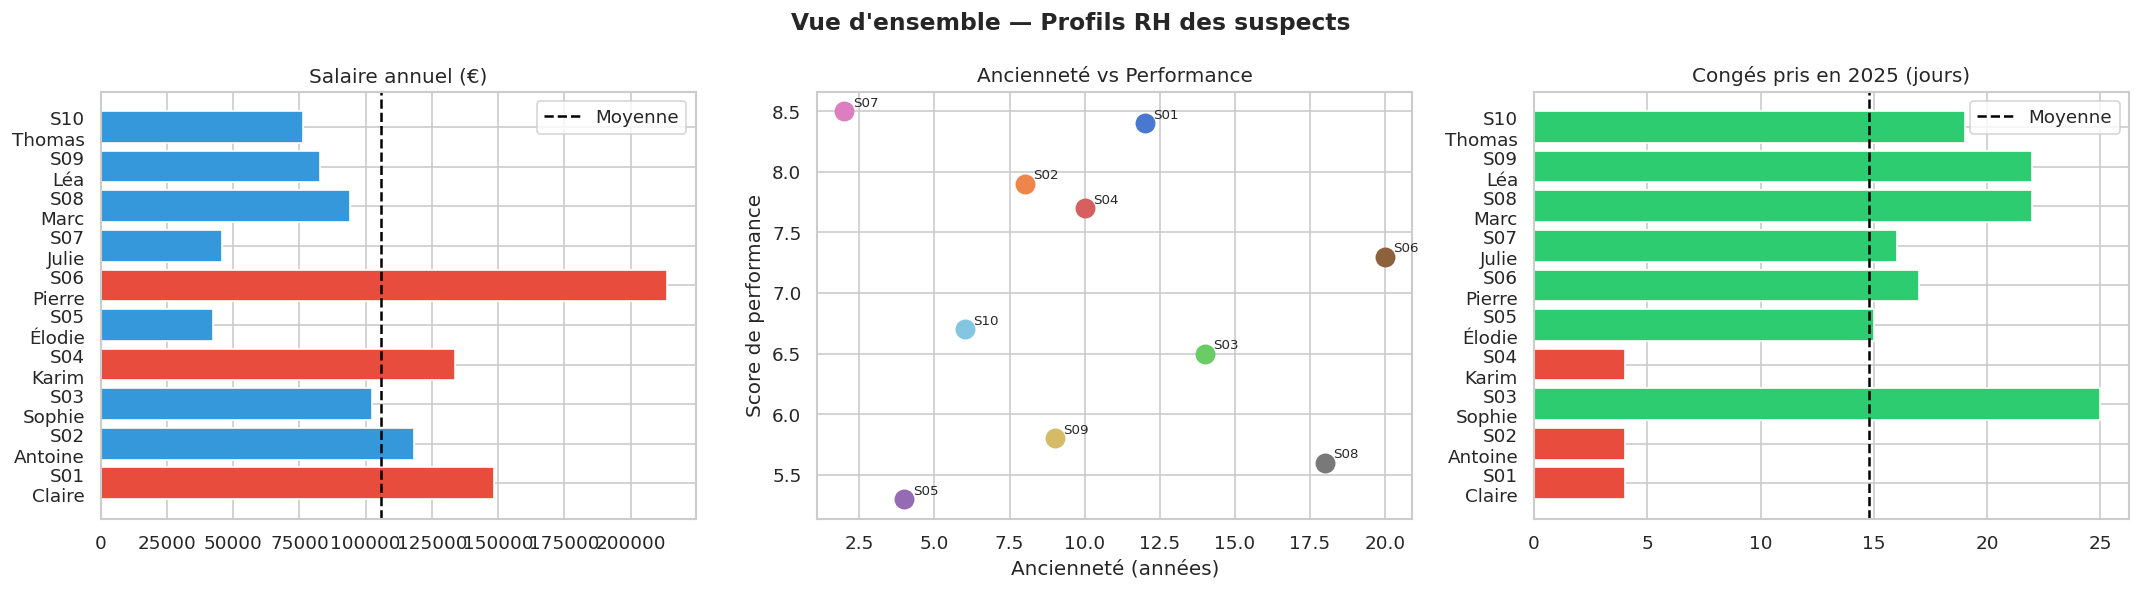

✅ Graphique RH sauvegardé.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Vue d'ensemble — Profils RH des suspects", fontsize=14, fontweight="bold")

labels = [f"{row['id_suspect']}\n{row['prenom']}" for _, row in employes.iterrows()]

# --- Salaire ---
colors_salaire = ["#e74c3c" if s > 130000 else "#3498db" for s in employes["salaire_annuel_eur"]]
axes[0].barh(labels, employes["salaire_annuel_eur"], color=colors_salaire)
axes[0].set_title("Salaire annuel (€)")
axes[0].axvline(employes["salaire_annuel_eur"].mean(), color="black", linestyle="--", label="Moyenne")
axes[0].legend()

# --- Ancienneté vs Performance ---
for _, row in employes.iterrows():
    axes[1].scatter(row["anciennete_annees"], row["performance_score"], s=120, zorder=3)
    axes[1].annotate(row["id_suspect"], (row["anciennete_annees"], row["performance_score"]),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[1].set_xlabel("Ancienneté (années)")
axes[1].set_ylabel("Score de performance")
axes[1].set_title("Ancienneté vs Performance")

# --- Congés pris ---
colors_conges = ["#e74c3c" if c <= 5 else "#2ecc71" for c in employes["conges_pris_2025_jours"]]
axes[2].barh(labels, employes["conges_pris_2025_jours"], color=colors_conges)
axes[2].axvline(employes["conges_pris_2025_jours"].mean(), color="black", linestyle="--", label="Moyenne")
axes[2].set_title("Congés pris en 2025 (jours)")
axes[2].legend()

plt.tight_layout()
plt.savefig("01_profils_rh.png", bbox_inches="tight")
plt.show()
print("✅ Graphique RH sauvegardé.")

# Heatmap des preuves matérielles

/tmp/ipykernel_108996/3945057064.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  preuves_bin = preuves.set_index("id_suspect")[cols_preuves].replace({"oui": 1, "non": 0, True: 1, False: 0})
/tmp/ipykernel_108996/3945057064.py:19: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/3945057064.py:20: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig("02_preuves_materielles.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


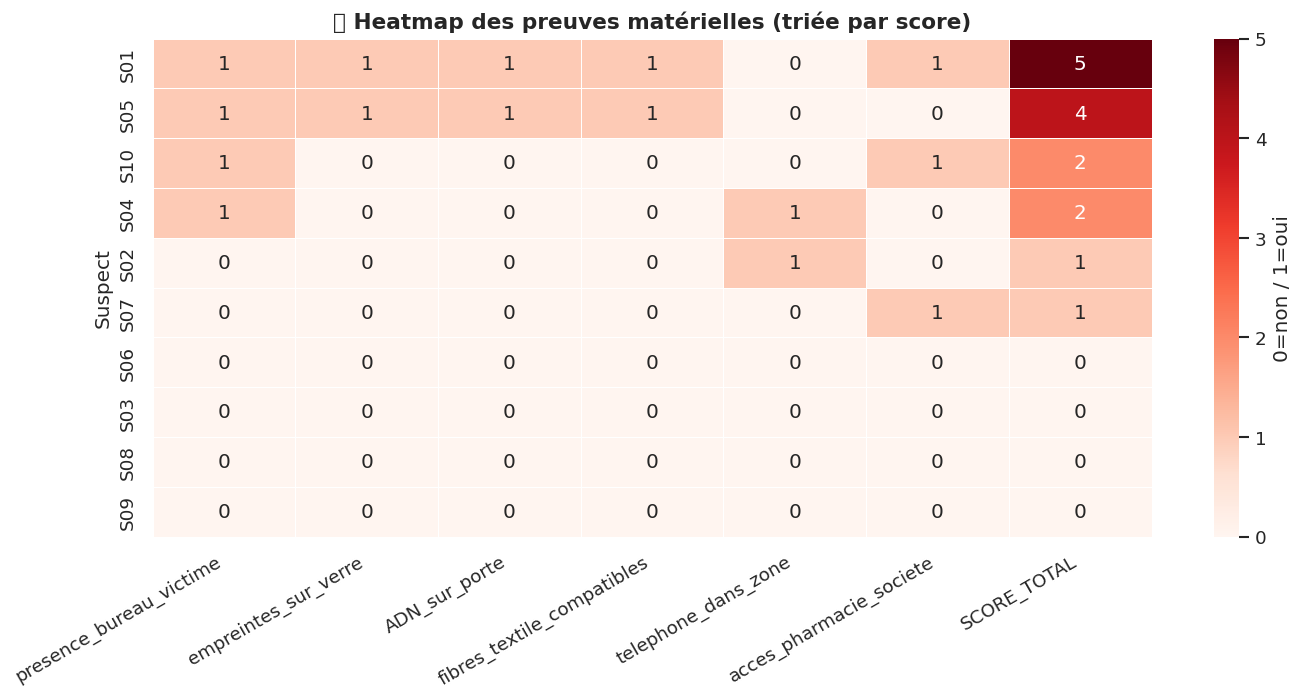

✅ Heatmap sauvegardée.

📊 Score total de preuves par suspect :
id_suspect
S01    5
S05    4
S10    2
S04    2
S02    1
S07    1
S06    0
S03    0
S08    0
S09    0
Name: SCORE_TOTAL, dtype: int64


In [4]:
# --- Heatmap preuves matérielles ---
cols_preuves = ["presence_bureau_victime", "empreintes_sur_verre",
                "ADN_sur_porte", "fibres_textile_compatibles",
                "telephone_dans_zone", "acces_pharmacie_societe"]

preuves_bin = preuves.set_index("id_suspect")[cols_preuves].replace({"oui": 1, "non": 0, True: 1, False: 0})

# Score total de preuves par suspect
preuves_bin["SCORE_TOTAL"] = preuves_bin.sum(axis=1)
preuves_bin = preuves_bin.sort_values("SCORE_TOTAL", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(preuves_bin, annot=True, fmt="d", cmap="Reds",
            linewidths=0.5, ax=ax, cbar_kws={"label": "0=non / 1=oui"})
ax.set_title("🔬 Heatmap des preuves matérielles (triée par score)", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Suspect")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("02_preuves_materielles.png", bbox_inches="tight")
plt.show()
print("✅ Heatmap sauvegardée.")
print("\n📊 Score total de preuves par suspect :")
print(preuves_bin["SCORE_TOTAL"])

# Timeline des accès le soir du meurtre

/tmp/ipykernel_108996/1287302002.py:51: UserWarning: Glyph 128373 (\N{SLEUTH OR SPY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/1287302002.py:52: UserWarning: Glyph 128373 (\N{SLEUTH OR SPY}) missing from font(s) DejaVu Sans.
  plt.savefig("03_timeline_meurtre.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128373 (\N{SLEUTH OR SPY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


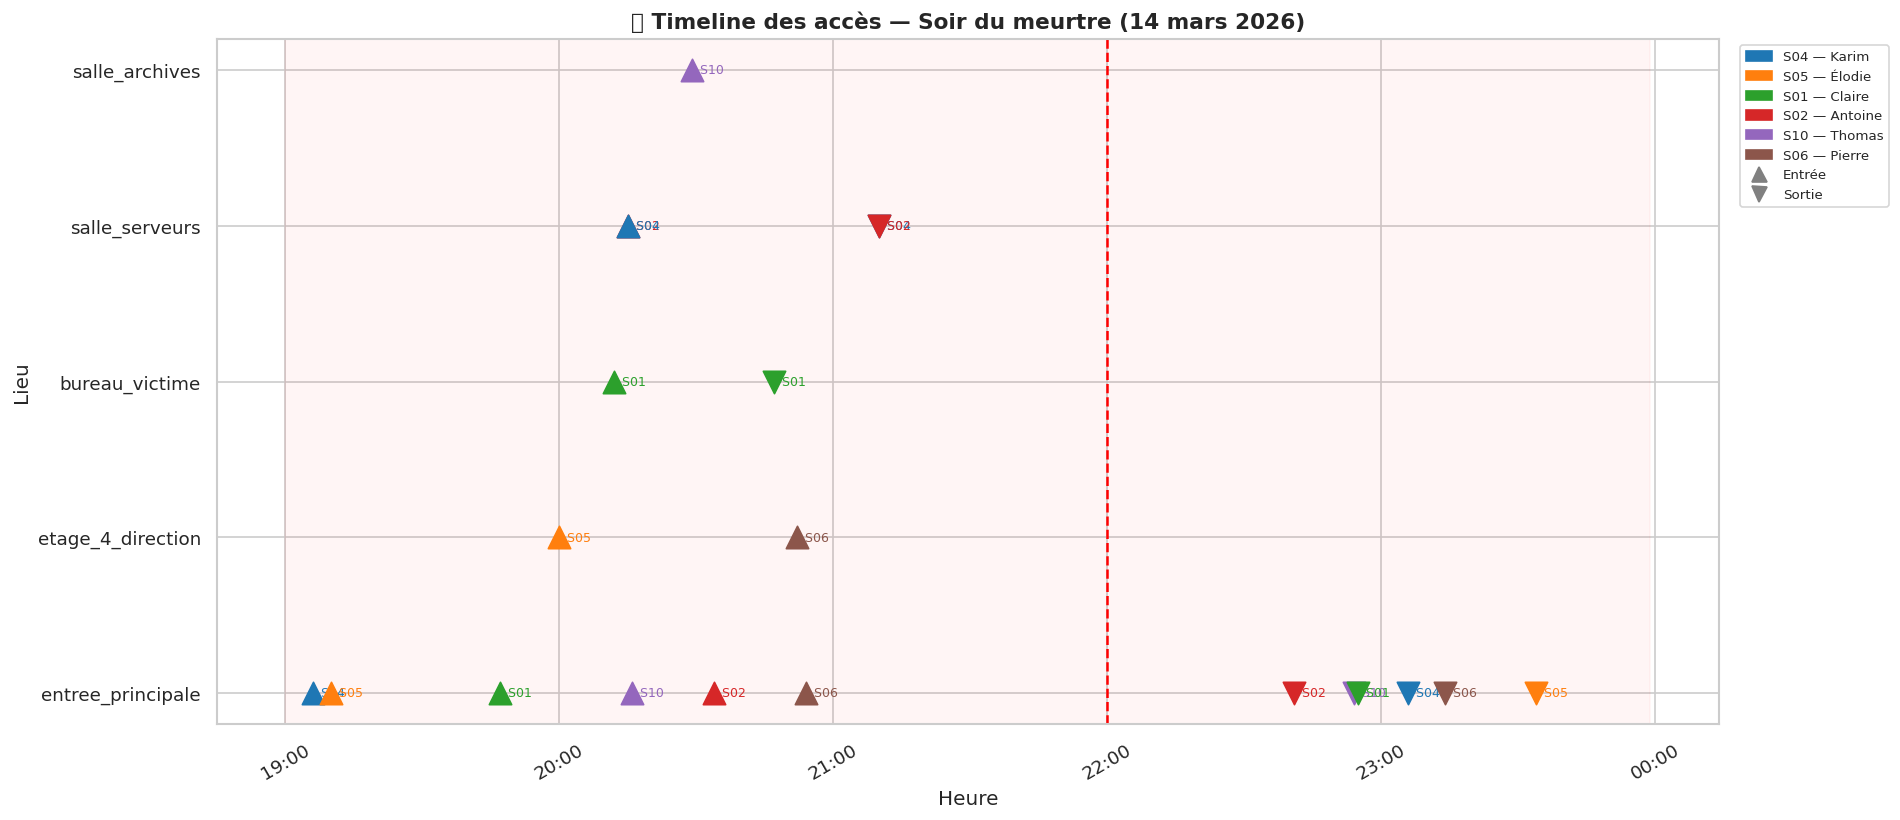

✅ Timeline sauvegardée.


In [5]:

import matplotlib.patches as mpatches

# Filtrer le soir du meurtre
logs_acces["timestamp"] = pd.to_datetime(logs_acces["timestamp"])
soir = logs_acces[logs_acces["timestamp"].dt.date == pd.Timestamp("2026-03-14").date()].copy()

# Correspondance ID → prénom pour les labels
noms = employes.set_index("id_suspect")["prenom"].to_dict()
soir["label"] = soir["id_suspect"].map(noms) + " (" + soir["id_suspect"] + ")"

# Couleur par suspect
suspects_presents = soir["id_suspect"].unique()
palette = sns.color_palette("tab10", len(suspects_presents))
couleurs = dict(zip(suspects_presents, palette))

# Forme : entrée = triangle haut, sortie = triangle bas
markers = {"entree": "^", "sortie": "v"}

fig, ax = plt.subplots(figsize=(16, 7))

for _, row in soir.iterrows():
    ax.scatter(row["timestamp"], row["lieu"],
               color=couleurs[row["id_suspect"]],
               marker=markers[row["action"]],
               s=180, zorder=3)
    ax.text(row["timestamp"], row["lieu"],
            f"  {row['id_suspect']}", fontsize=7.5,
            va="center", color=couleurs[row["id_suspect"]])

# Zone critique : heure du meurtre estimée (~22h)
ax.axvspan(pd.Timestamp("2026-03-14 19:00"), pd.Timestamp("2026-03-14 23:59"),
           alpha=0.04, color="red", label="Fenêtre temporelle du crime")
ax.axvline(pd.Timestamp("2026-03-14 22:00"), color="red",
           linestyle="--", linewidth=1.5, label="Heure estimée du décès (~22h)")

# Légende suspects
legend_suspects = [mpatches.Patch(color=couleurs[s],
                   label=f"{s} — {noms[s]}") for s in suspects_presents]
legend_shapes = [
    plt.Line2D([0],[0], marker="^", color="gray", linestyle="None", markersize=9, label="Entrée"),
    plt.Line2D([0],[0], marker="v", color="gray", linestyle="None", markersize=9, label="Sortie"),
]
ax.legend(handles=legend_suspects + legend_shapes,
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

ax.set_title("🕵️ Timeline des accès — Soir du meurtre (14 mars 2026)", fontsize=13, fontweight="bold")
ax.set_xlabel("Heure")
ax.set_ylabel("Lieu")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("03_timeline_meurtre.png", bbox_inches="tight")
plt.show()
print("✅ Timeline sauvegardée.")

In [6]:

print("=" * 60)
print("📍 PRÉSENCES CE SOIR — 14 MARS 2026")
print("=" * 60)

for suspect in sorted(soir["id_suspect"].unique()):
    subset = soir[soir["id_suspect"] == suspect].sort_values("timestamp")
    print(f"\n🔹 {suspect} — {noms[suspect]}")
    for _, row in subset.iterrows():
        print(f"   {row['timestamp'].strftime('%H:%M')}  {row['action']:7s}  {row['lieu']}")

# Qui était au bureau de la victime ?
print("\n" + "=" * 60)
print("🚨 ACCÈS AU BUREAU DE LA VICTIME ce soir-là :")
bureau = soir[soir["lieu"] == "bureau_victime"]
for _, row in bureau.iterrows():
    print(f"   ➜ {row['id_suspect']} ({noms[row['id_suspect']]}) "
          f"— {row['action']} à {row['timestamp'].strftime('%H:%M')}")

📍 PRÉSENCES CE SOIR — 14 MARS 2026

🔹 S01 — Claire
   19:47  entree   entree_principale
   20:12  entree   bureau_victime
   20:47  sortie   bureau_victime
   22:55  sortie   entree_principale

🔹 S02 — Antoine
   20:15  entree   salle_serveurs
   20:34  entree   entree_principale
   21:10  sortie   salle_serveurs
   22:41  sortie   entree_principale

🔹 S04 — Karim
   19:06  entree   entree_principale
   20:15  entree   salle_serveurs
   21:10  sortie   salle_serveurs
   23:06  sortie   entree_principale

🔹 S05 — Élodie
   19:10  entree   entree_principale
   20:00  entree   etage_4_direction
   23:34  sortie   entree_principale

🔹 S06 — Pierre
   20:52  entree   etage_4_direction
   20:54  entree   entree_principale
   23:14  sortie   entree_principale

🔹 S10 — Thomas
   20:16  entree   entree_principale
   20:29  entree   salle_archives
   22:54  sortie   entree_principale

🚨 ACCÈS AU BUREAU DE LA VICTIME ce soir-là :
   ➜ S01 (Claire) — entree à 20:12
   ➜ S01 (Claire) — sortie à 20:

# Analyse des transactions suspectes

In [7]:

transactions["date"] = pd.to_datetime(transactions["date"])

# Isoler les virements offshore (Îles Caïmans, Panama, Îles Vierges)
offshore = transactions[transactions["beneficiaire_pays"].isin(["KY", "PA", "VG"])].copy()

print(f"💰 Total virements offshore : {len(offshore)} transactions")
print(f"💰 Montant total            : {offshore['montant_eur'].sum():,.0f} €")
print(f"\n📊 Répartition par pays :")
print(offshore.groupby("beneficiaire_pays")["montant_eur"].agg(["count", "sum", "mean"]).round(0))

💰 Total virements offshore : 188 transactions
💰 Montant total            : 5,687,044 €

📊 Répartition par pays :
                   count        sum     mean
beneficiaire_pays                           
KY                    73  2369154.0  32454.0
PA                    59  1673736.0  28368.0
VG                    56  1644154.0  29360.0


/tmp/ipykernel_108996/372714536.py:35: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/372714536.py:36: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.savefig("04_transactions_offshore.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


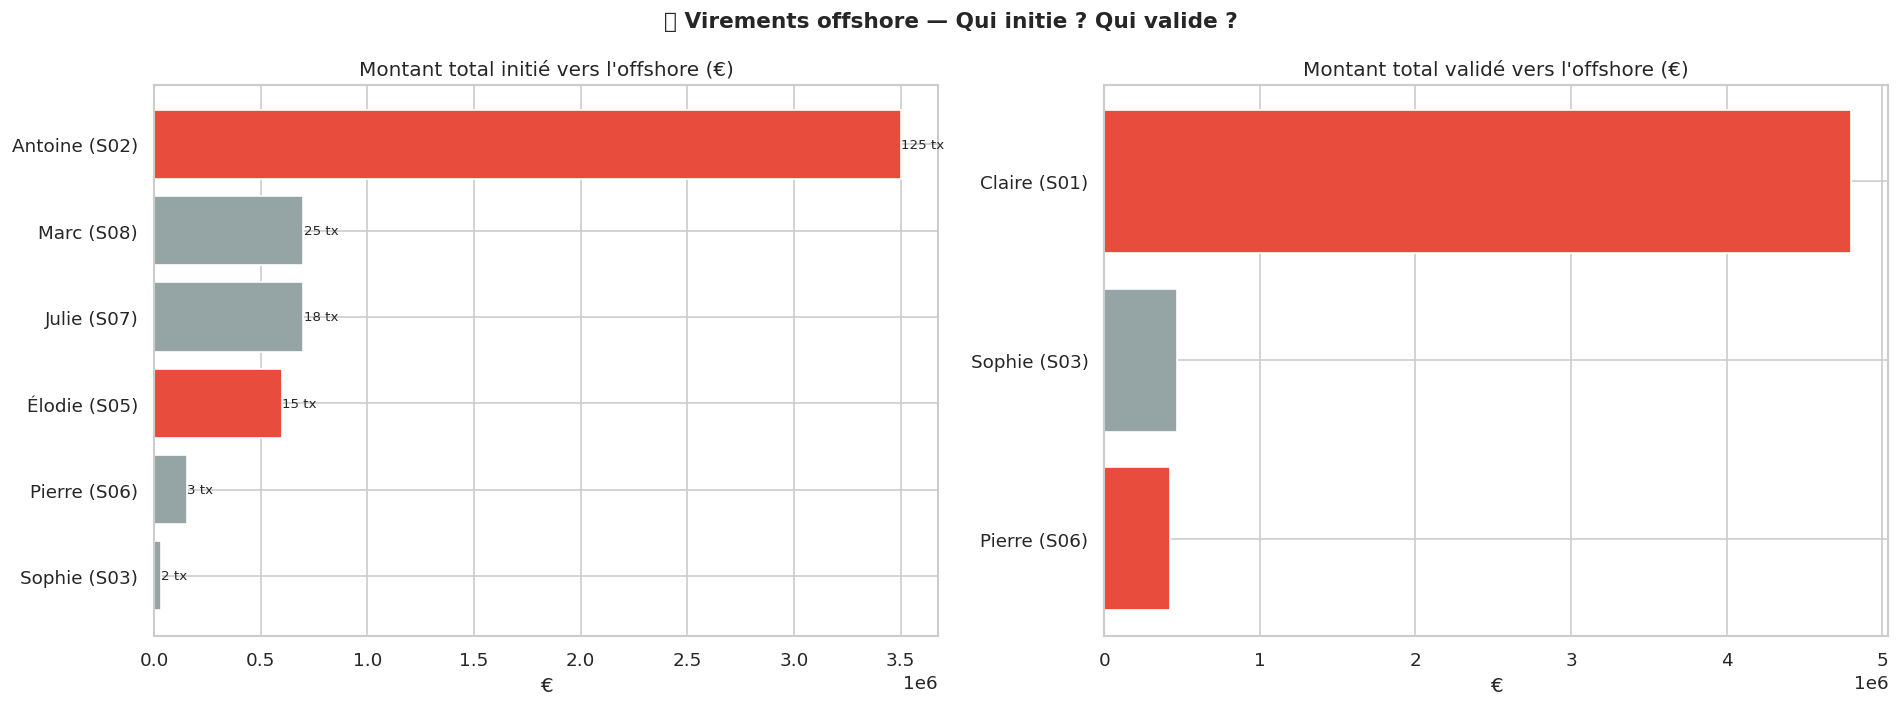

In [8]:
# --- Qui initie les virements offshore ? ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("💸 Virements offshore — Qui initie ? Qui valide ?",
             fontsize=13, fontweight="bold")

# Initiateurs
init_counts = offshore.groupby("id_suspect_initiateur")["montant_eur"].agg(["count","sum"])
init_counts["label"] = init_counts.index.map(noms)
init_counts = init_counts.sort_values("sum", ascending=True)

colors_init = ["#e74c3c" if s in ["S01","S02","S04","S05"] else "#95a5a6"
               for s in init_counts.index]

bars = axes[0].barh(init_counts["label"] + " (" + init_counts.index + ")",
                    init_counts["sum"], color=colors_init)
axes[0].set_title("Montant total initié vers l'offshore (€)")
axes[0].set_xlabel("€")
for bar, (_, row) in zip(bars, init_counts.iterrows()):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f"{int(row['count'])} tx", va="center", fontsize=8)

# Validateurs
val_counts = offshore.groupby("validateur_id")["montant_eur"].agg(["count","sum"])
val_counts["label"] = val_counts.index.map(noms)
val_counts = val_counts.sort_values("sum", ascending=True)

colors_val = ["#e74c3c" if s in ["S01","S06"] else "#95a5a6"
              for s in val_counts.index]

axes[1].barh(val_counts["label"] + " (" + val_counts.index + ")",
             val_counts["sum"], color=colors_val)
axes[1].set_title("Montant total validé vers l'offshore (€)")
axes[1].set_xlabel("€")

plt.tight_layout()
plt.savefig("04_transactions_offshore.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_108996/3474538913.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/3474538913.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("05_evolution_offshore.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


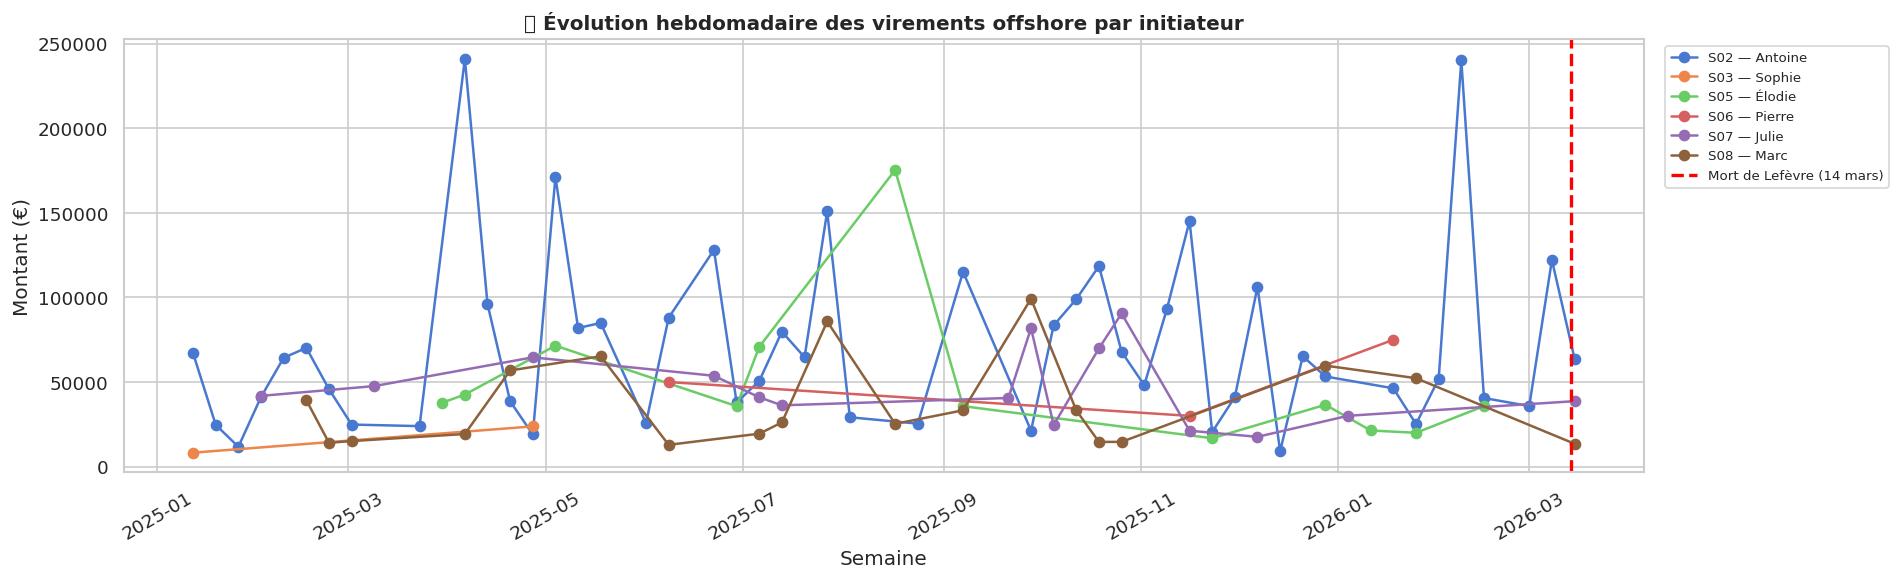

✅ Graphiques transactions sauvegardés.


In [9]:
# --- Évolution temporelle des virements offshore ---
fig, ax = plt.subplots(figsize=(16, 5))

offshore_hebdo = offshore.groupby([pd.Grouper(key="date", freq="W"),
                                   "id_suspect_initiateur"])["montant_eur"].sum().reset_index()

for suspect, group in offshore_hebdo.groupby("id_suspect_initiateur"):
    ax.plot(group["date"], group["montant_eur"],
            marker="o", label=f"{suspect} — {noms[suspect]}", linewidth=1.5)

# Marquer la mort de Lefèvre
ax.axvline(pd.Timestamp("2026-03-14"), color="red",
           linestyle="--", linewidth=2, label="Mort de Lefèvre (14 mars)")

ax.set_title("📈 Évolution hebdomadaire des virements offshore par initiateur",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Semaine")
ax.set_ylabel("Montant (€)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("05_evolution_offshore.png", bbox_inches="tight")
plt.show()
print("✅ Graphiques transactions sauvegardés.")

In [10]:
# --- Complicité : qui valide les transactions de qui ? ---
print("\n" + "="*60)
print("🤝 BINÔMES INITIATEUR → VALIDATEUR (offshore uniquement)")
print("="*60)

binomes = offshore.groupby(["id_suspect_initiateur","validateur_id"])["montant_eur"]\
                  .agg(["count","sum"]).reset_index()
binomes = binomes.sort_values("sum", ascending=False)
binomes["initiateur"] = binomes["id_suspect_initiateur"].map(noms)
binomes["validateur"] = binomes["validateur_id"].map(noms)

for _, row in binomes.head(10).iterrows():
    print(f"   {row['initiateur']:10s} → validé par {row['validateur']:10s} "
          f"| {int(row['count']):3d} tx | {row['sum']:>10,.0f} €")


🤝 BINÔMES INITIATEUR → VALIDATEUR (offshore uniquement)
   Antoine    → validé par Claire     | 125 tx |  3,500,000 €
   Julie      → validé par Claire     |  18 tx |    700,000 €
   Élodie     → validé par Claire     |  15 tx |    600,000 €
   Marc       → validé par Pierre     |  13 tx |    389,329 €
   Marc       → validé par Sophie     |  12 tx |    310,671 €
   Pierre     → validé par Sophie     |   3 tx |    155,000 €
   Sophie     → validé par Pierre     |   2 tx |     32,044 €


# Analyse des interrogatoires (tests statistiques)

In [11]:
# Diagnostic : structure des interrogatoires


print("Colonnes :", interrogatoires.columns.tolist())
print("\nType de questions distincts :")
print(interrogatoires["type_question"].value_counts())
print("\nNombre de questions par suspect et type :")
print(interrogatoires.groupby(["id_suspect", "type_question"])["num_question"].count().unstack())

Colonnes : ['id_suspect', 'num_question', 'type_question', 'texte_question', 'rythme_cardiaque_bpm', 'temps_reponse_sec']

Type de questions distincts :
type_question
neutre         150
accusatrice    150
Name: count, dtype: int64

Nombre de questions par suspect et type :
type_question  accusatrice  neutre
id_suspect                        
S01                     15      15
S02                     15      15
S03                     15      15
S04                     15      15
S05                     15      15
S06                     15      15
S07                     15      15
S08                     15      15
S09                     15      15
S10                     15      15


In [12]:

print("=" * 70)
print("🫀 T-TEST APPARIÉ : BPM neutre vs accusatrice (par suspect)")
print("=" * 70)
print(f"{'Suspect':<6} {'Prénom':<10} {'BPM_neutre':>10} {'BPM_accus':>10} {'Δ BPM':>7} {'p-value':>10} {'Sig.':>8}")
print("-" * 70)

resultats_bpm = []

for sid in sorted(interrogatoires["id_suspect"].unique()):
    bpm_n = interrogatoires[(interrogatoires["id_suspect"] == sid) &
                             (interrogatoires["type_question"] == "neutre")]["rythme_cardiaque_bpm"].values
    bpm_a = interrogatoires[(interrogatoires["id_suspect"] == sid) &
                             (interrogatoires["type_question"] == "accusatrice")]["rythme_cardiaque_bpm"].values

    # Normalité des différences (Shapiro-Wilk)
    diff = bpm_a - bpm_n
    _, p_shapiro = stats.shapiro(diff)

    # T-test apparié
    t_stat, p_val = stats.ttest_rel(bpm_n, bpm_a)

    delta = bpm_a.mean() - bpm_n.mean()
    sig = "🚨 OUI" if p_val < 0.05 else "non"

    resultats_bpm.append({
        "id_suspect": sid, "prenom": noms[sid],
        "bpm_neutre": round(bpm_n.mean(), 1),
        "bpm_accus":  round(bpm_a.mean(), 1),
        "delta":      round(delta, 1),
        "p_value":    round(p_val, 4),
        "p_shapiro":  round(p_shapiro, 4),
        "significatif": p_val < 0.05
    })

    print(f"{sid:<6} {noms[sid]:<10} {bpm_n.mean():>10.1f} {bpm_a.mean():>10.1f} "
          f"{delta:>+7.1f} {p_val:>10.4f} {sig:>8}")

df_bpm = pd.DataFrame(resultats_bpm)

🫀 T-TEST APPARIÉ : BPM neutre vs accusatrice (par suspect)
Suspect Prénom     BPM_neutre  BPM_accus   Δ BPM    p-value     Sig.
----------------------------------------------------------------------
S01    Claire           71.5       94.2   +22.7     0.0000    🚨 OUI
S02    Antoine          69.9       95.8   +25.9     0.0000    🚨 OUI
S03    Sophie           68.4       73.9    +5.5     0.0045    🚨 OUI
S04    Karim            68.1       93.2   +25.1     0.0000    🚨 OUI
S05    Élodie           73.9       81.9    +8.0     0.0011    🚨 OUI
S06    Pierre           71.5       69.9    -1.5     0.4934      non
S07    Julie            71.4       71.6    +0.2     0.9306      non
S08    Marc             70.3       72.7    +2.4     0.1504      non
S09    Léa              71.3       72.8    +1.5     0.3004      non
S10    Thomas           72.0       71.8    -0.2     0.9028      non


/tmp/ipykernel_108996/2652824541.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([bpm_n, bpm_a], labels=["Neutre", "Accus."], patch_artist=True,
/tmp/ipykernel_108996/2652824541.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([bpm_n, bpm_a], labels=["Neutre", "Accus."], patch_artist=True,
/tmp/ipykernel_108996/2652824541.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([bpm_n, bpm_a], labels=["Neutre", "Accus."], patch_artist=True,
/tmp/ipykernel_108996/2652824541.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since

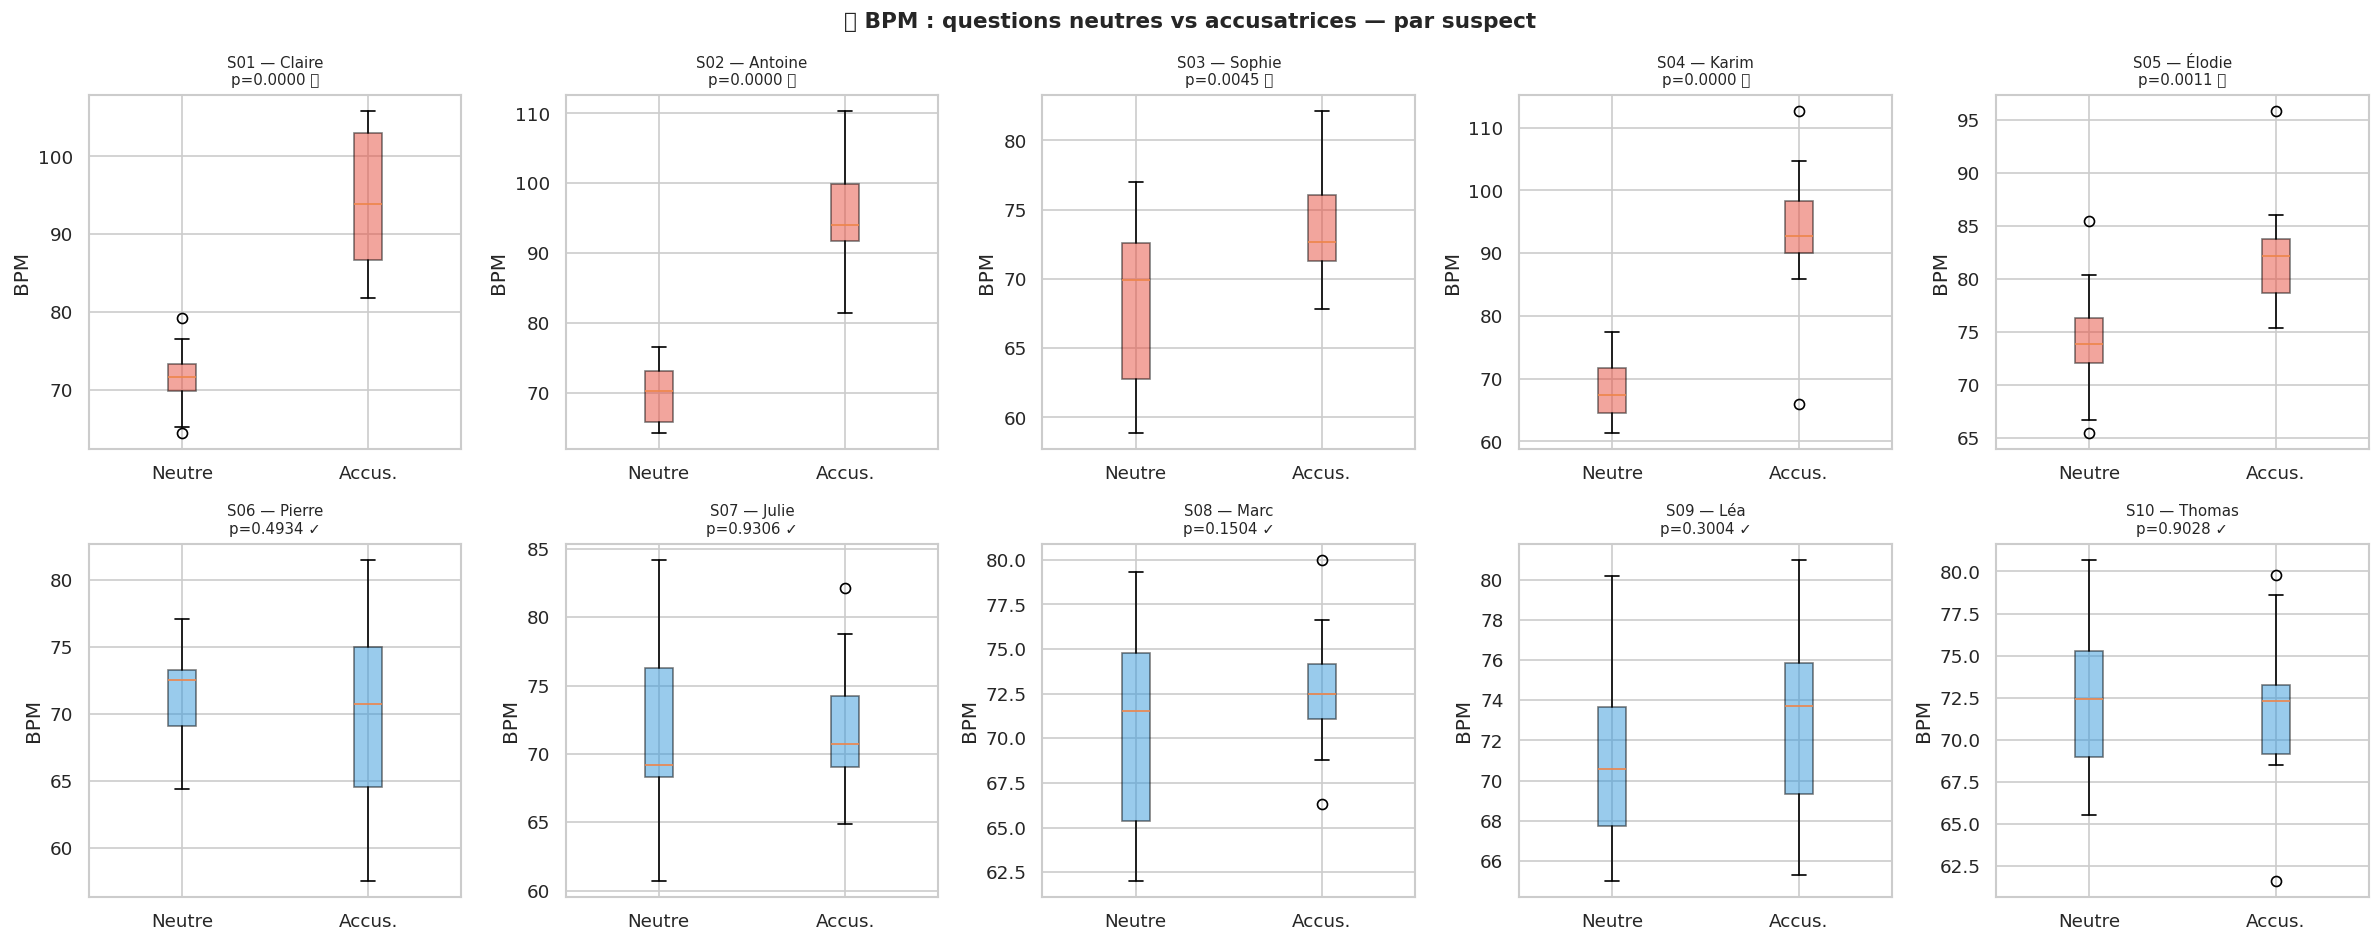

In [13]:
# --- Boxplots BPM par suspect ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("🫀 BPM : questions neutres vs accusatrices — par suspect",
             fontsize=13, fontweight="bold")

for ax, sid in zip(axes.flatten(), sorted(interrogatoires["id_suspect"].unique())):
    bpm_n = interrogatoires[(interrogatoires["id_suspect"] == sid) &
                             (interrogatoires["type_question"] == "neutre")]["rythme_cardiaque_bpm"]
    bpm_a = interrogatoires[(interrogatoires["id_suspect"] == sid) &
                             (interrogatoires["type_question"] == "accusatrice")]["rythme_cardiaque_bpm"]

    row = df_bpm[df_bpm["id_suspect"] == sid].iloc[0]
    color = "#e74c3c" if row["significatif"] else "#3498db"

    ax.boxplot([bpm_n, bpm_a], labels=["Neutre", "Accus."], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5))
    ax.set_title(f"{sid} — {noms[sid]}\np={row['p_value']:.4f} {'🚨' if row['significatif'] else '✓'}",
                 fontsize=9)
    ax.set_ylabel("BPM")

plt.tight_layout()
plt.savefig("06_bpm_interrogatoires.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_108996/1092569012.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/1092569012.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("07_delta_bpm.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


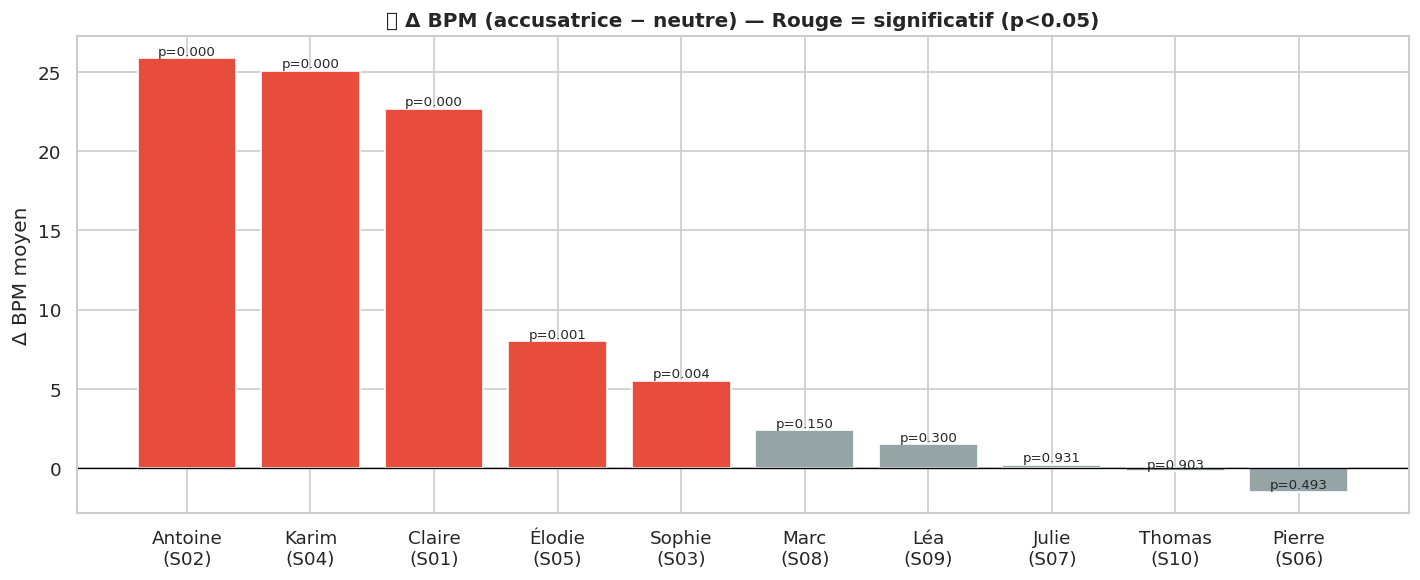

✅ Graphiques BPM sauvegardés.


In [14]:
# --- Bar chart Δ BPM ---
df_bpm_sorted = df_bpm.sort_values("delta", ascending=False)
colors = ["#e74c3c" if sig else "#95a5a6" for sig in df_bpm_sorted["significatif"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_bpm_sorted["prenom"] + "\n(" + df_bpm_sorted["id_suspect"] + ")",
              df_bpm_sorted["delta"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("📊 Δ BPM (accusatrice − neutre) — Rouge = significatif (p<0.05)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Δ BPM moyen")

for bar, (_, row) in zip(bars, df_bpm_sorted.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f"p={row['p_value']:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("07_delta_bpm.png", bbox_inches="tight")
plt.show()
print("✅ Graphiques BPM sauvegardés.")

# Machine Learning : PCA + K-Means

In [15]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- Agrégation de toutes les features par suspect ---

# 1. RH
rh = employes[["id_suspect", "anciennete_annees", "salaire_annuel_eur",
                "conges_pris_2025_jours", "performance_score"]].copy()
rh["acces_pharmacie"] = employes["acces_pharmacie_societe"].map({True: 1, False: 0,
                                                                   "TRUE": 1, "FALSE": 0})

# 2. Transactions offshore
tx_off = offshore.groupby("id_suspect_initiateur").agg(
    nb_tx_offshore=("montant_eur", "count"),
    montant_offshore=("montant_eur", "sum")
).reset_index().rename(columns={"id_suspect_initiateur": "id_suspect"})

tx_val = offshore.groupby("validateur_id").agg(
    nb_tx_validees=("montant_eur", "count"),
    montant_valide=("montant_eur", "sum")
).reset_index().rename(columns={"validateur_id": "id_suspect"})

# 3. BPM
bpm_feats = df_bpm[["id_suspect", "bpm_neutre", "bpm_accus", "delta"]].copy()

# 4. Preuves matérielles
preuves_score = preuves_bin[["SCORE_TOTAL"]].reset_index()

# 5. Logs : nb d'accès bureau victime + pharmacie (tous temps)
logs_bureau = logs_acces[logs_acces["lieu"] == "bureau_victime"]\
              .groupby("id_suspect").size().reset_index(name="nb_acces_bureau")
logs_pharma = logs_acces[logs_acces["lieu"].str.contains("pharma", case=False, na=False)]\
              .groupby("id_suspect").size().reset_index(name="nb_acces_pharmacie_log")

# --- Fusion ---
profil = rh.copy()
for df_tmp in [tx_off, tx_val, bpm_feats, preuves_score, logs_bureau, logs_pharma]:
    profil = profil.merge(df_tmp, on="id_suspect", how="left")

profil = profil.fillna(0)
profil = profil.set_index("id_suspect")

print("✅ Profil composite :")
print(profil.to_string())

✅ Profil composite :
            anciennete_annees  salaire_annuel_eur  conges_pris_2025_jours  performance_score  acces_pharmacie  nb_tx_offshore  montant_offshore  nb_tx_validees  montant_valide  bpm_neutre  bpm_accus  delta  SCORE_TOTAL  nb_acces_bureau  nb_acces_pharmacie_log
id_suspect                                                                                                                                                                                                                                                         
S01                        12              148601                       4                8.4                1             0.0              0.00           158.0      4800000.00        71.5       94.2   22.7            5              2.0                     0.0
S02                         8              118376                       4                7.9                0           125.0        3500000.00             0.0            0.00        69.9       95.8 

In [16]:
# --- PCA + K-Means ---
features = [
            "performance_score", "acces_pharmacie",
            "nb_tx_offshore", "montant_offshore",
            "nb_tx_validees", "montant_valide",
            "bpm_neutre", "bpm_accus", "delta",
            "SCORE_TOTAL", "nb_acces_bureau"]

X = profil[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"📊 Variance expliquée : PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"Total={sum(pca.explained_variance_ratio_):.1%}")

# K-Means k=2 (innocents vs suspects)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
profil["cluster"] = clusters

📊 Variance expliquée : PC1=36.4%, PC2=26.2%, Total=62.7%


/tmp/ipykernel_108996/1954346802.py:36: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/1954346802.py:37: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig("08_pca_kmeans.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


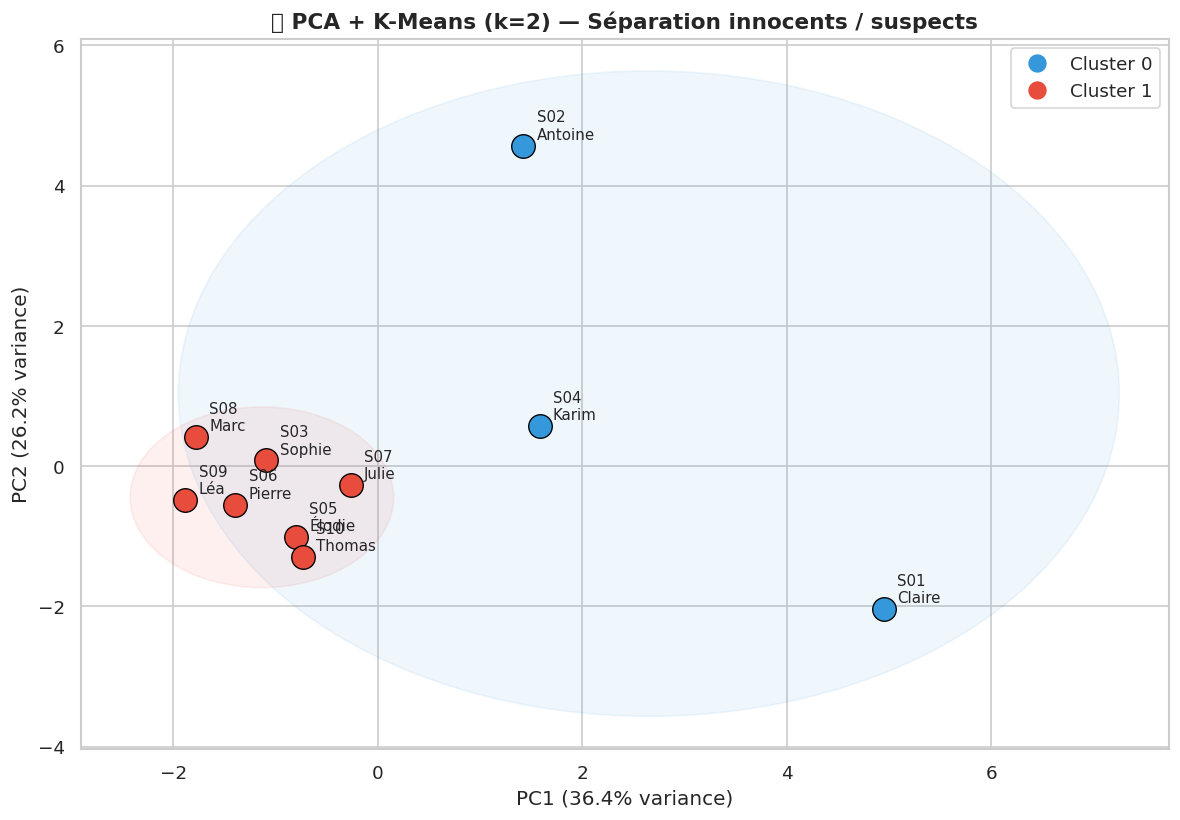


📊 Cluster par suspect :
   S01 — Claire     → Cluster 0
   S02 — Antoine    → Cluster 0
   S03 — Sophie     → Cluster 1
   S04 — Karim      → Cluster 0
   S05 — Élodie     → Cluster 1
   S06 — Pierre     → Cluster 1
   S07 — Julie      → Cluster 1
   S08 — Marc       → Cluster 1
   S09 — Léa        → Cluster 1
   S10 — Thomas     → Cluster 1


In [17]:
# --- Visualisation PCA ---
fig, ax = plt.subplots(figsize=(10, 7))

couleurs_cluster = {0: "#3498db", 1: "#e74c3c"}
labels_cluster   = {0: "Groupe A", 1: "Groupe B"}

for sid in profil.index:
    c = profil.loc[sid, "cluster"]
    x, y = X_pca[list(profil.index).index(sid)]
    ax.scatter(x, y, color=couleurs_cluster[c], s=200, zorder=3,
               edgecolors="black", linewidths=0.8)
    ax.annotate(f"{sid}\n{noms[sid]}", (x, y),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Ellipses par cluster
for c in [0, 1]:
    idx = [i for i, sid in enumerate(profil.index) if profil.loc[sid, "cluster"] == c]
    pts = X_pca[idx]
    if len(pts) > 1:
        center = pts.mean(axis=0)
        radius = np.max(np.linalg.norm(pts - center, axis=1)) * 1.2
        circle = plt.Circle(center, radius, color=couleurs_cluster[c],
                            alpha=0.08, zorder=1)
        ax.add_patch(circle)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("🧠 PCA + K-Means (k=2) — Séparation innocents / suspects",
             fontsize=13, fontweight="bold")

from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker="o", color="w", markerfacecolor=couleurs_cluster[c],
                 markersize=12, label=f"Cluster {c}") for c in [0,1]]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig("08_pca_kmeans.png", bbox_inches="tight")
plt.show()

print("\n📊 Cluster par suspect :")
for sid in sorted(profil.index):
    print(f"   {sid} — {noms[sid]:<10} → Cluster {profil.loc[sid,'cluster']}")

📍 S04 Karim — Lieux fréquentés sur 90 jours :
lieu
parking              391
salle_serveurs       390
etage_3_IT           363
entree_principale    345
Name: count, dtype: int64

📍 Accès spécifiques salle_serveurs et bureau_victime :
                timestamp            lieu  action
43    2025-12-14 12:20:04  salle_serveurs  sortie
237   2025-12-16 03:47:06  salle_serveurs  sortie
239   2025-12-16 05:46:51  salle_serveurs  entree
262   2025-12-16 10:38:06  salle_serveurs  sortie
266   2025-12-16 11:13:12  salle_serveurs  entree
278   2025-12-16 12:47:17  salle_serveurs  entree
285   2025-12-16 14:11:08  salle_serveurs  sortie
293   2025-12-16 15:08:41  salle_serveurs  entree
310   2025-12-16 16:51:53  salle_serveurs  sortie
432   2025-12-17 16:21:34  salle_serveurs  entree
466   2025-12-17 23:13:05  salle_serveurs  sortie
467   2025-12-17 23:29:38  salle_serveurs  entree
515   2025-12-18 12:14:14  salle_serveurs  entree
570   2025-12-18 18:11:23  salle_serveurs  sortie
580   2025-12-18 

/tmp/ipykernel_108996/830359313.py:24: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/830359313.py:25: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig("10_acces_serveurs.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


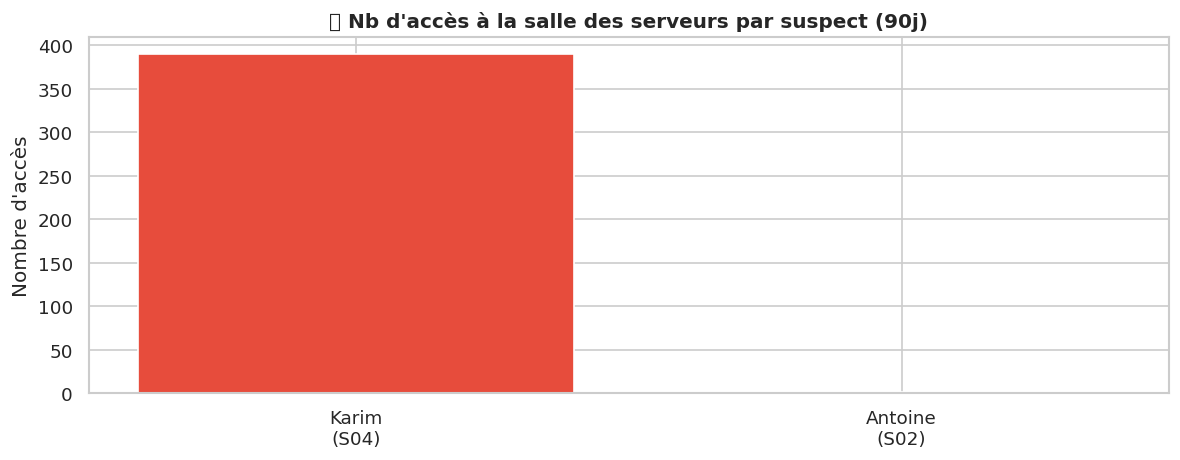

In [18]:

logs_s04 = logs_acces[logs_acces["id_suspect"] == "S04"].copy()
logs_s04["date"] = logs_s04["timestamp"].dt.date

print("📍 S04 Karim — Lieux fréquentés sur 90 jours :")
print(logs_s04["lieu"].value_counts())

print("\n📍 Accès spécifiques salle_serveurs et bureau_victime :")
lieux_cles = logs_s04[logs_s04["lieu"].isin(["salle_serveurs", "bureau_victime", "salle_archives"])]
print(lieux_cles.sort_values("timestamp")[["timestamp","lieu","action"]].to_string())

# Comparaison : nb d'accès salle_serveurs par suspect
acces_serveurs = logs_acces[logs_acces["lieu"] == "salle_serveurs"]\
                 .groupby("id_suspect").size().reset_index(name="nb_acces_serveurs")
acces_serveurs["prenom"] = acces_serveurs["id_suspect"].map(noms)
acces_serveurs = acces_serveurs.sort_values("nb_acces_serveurs", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors_srv = ["#e74c3c" if s == "S04" else "#95a5a6" for s in acces_serveurs["id_suspect"]]
ax.bar(acces_serveurs["prenom"] + "\n(" + acces_serveurs["id_suspect"] + ")",
       acces_serveurs["nb_acces_serveurs"], color=colors_srv)
ax.set_title("🖥️ Nb d'accès à la salle des serveurs par suspect (90j)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Nombre d'accès")
plt.tight_layout()
plt.savefig("10_acces_serveurs.png", bbox_inches="tight")
plt.show()

In [19]:
# --- Logs S04 autour du meurtre : semaine du 9 au 14 mars ---
print("\n🔍 S04 Karim — Activité semaine du meurtre (9-14 mars 2026) :")
s04_semaine = logs_acces[
    (logs_acces["id_suspect"] == "S04") &
    (logs_acces["timestamp"] >= "2026-03-09") &
    (logs_acces["timestamp"] <= "2026-03-15")
].sort_values("timestamp")
print(s04_semaine[["timestamp","lieu","action"]].to_string())

# Emails S04 : a-t-il communiqué avec S01 ou S02 ?
emails_s04 = emails[
    (emails["expediteur_id"] == "S04") | (emails["destinataire_id"] == "S04")
].copy()
print(f"\n📧 S04 impliqué dans {len(emails_s04)} emails")
print("Top correspondants :")
all_ids = pd.concat([emails_s04["expediteur_id"], emails_s04["destinataire_id"]])
print(all_ids[all_ids != "S04"].value_counts().head(5).to_string())


🔍 S04 Karim — Activité semaine du meurtre (9-14 mars 2026) :
                timestamp               lieu  action
10005 2026-03-09 00:14:37  entree_principale  entree
10008 2026-03-09 01:09:16         etage_3_IT  sortie
10012 2026-03-09 04:26:16         etage_3_IT  entree
10015 2026-03-09 08:18:57         etage_3_IT  entree
10033 2026-03-09 10:02:14         etage_3_IT  entree
10034 2026-03-09 10:15:19         etage_3_IT  sortie
10036 2026-03-09 10:21:41            parking  sortie
10051 2026-03-09 12:15:41         etage_3_IT  entree
10063 2026-03-09 13:47:30            parking  sortie
10066 2026-03-09 13:58:15            parking  entree
10074 2026-03-09 14:38:42            parking  entree
10088 2026-03-09 15:34:31            parking  sortie
10092 2026-03-09 16:17:15  entree_principale  sortie
10095 2026-03-09 16:22:26         etage_3_IT  sortie
10103 2026-03-09 17:08:22            parking  entree
10123 2026-03-09 19:52:00         etage_3_IT  entree
10131 2026-03-10 04:12:11  entree_pri

#  Tests statistiques formels pour la juge

In [20]:

from scipy.stats import norm

trio = ["S01", "S02", "S04"]
autres = ["S03", "S05", "S06", "S07", "S08", "S09", "S10"]

montants = transactions[transactions["beneficiaire_pays"].isin(["KY","PA","VG"])]\
           .groupby("id_suspect_initiateur")["montant_eur"].sum().reindex(
               employes["id_suspect"], fill_value=0)

s02_val   = [montants["S02"]]
autres_val = [montants[s] for s in autres]

montants_val = transactions[transactions["beneficiaire_pays"].isin(["KY","PA","VG"])]\
               .groupby("validateur_id")["montant_eur"].sum().reindex(
                   employes["id_suspect"], fill_value=0)


acces_srv = logs_acces[logs_acces["lieu"] == "salle_serveurs"]\
            .groupby("id_suspect").size().reindex(employes["id_suspect"], fill_value=0)

print("=" * 65)
print("⚖️  TESTS STATISTIQUES FORMELS ")
print("=" * 65)

# ── TEST 1 : S02 montant initié ───────────────────────────────────
print("\n📌 TEST 1 — Montant offshore initié (S02 vs distribution des autres)")
print("H0 : Le montant initié par S02 suit la distribution des autres")
print("H1 : S02 est un outlier significatif (queue supérieure)\n")

val_autres = np.array([montants[s] for s in autres], dtype=float)
mu1, sigma1 = val_autres.mean(), val_autres.std(ddof=1)
z1 = (montants["S02"] - mu1) / sigma1
p1 = 1 - norm.cdf(z1)

print(f"   Montant S02        : {montants['S02']:>12,.0f} €")
print(f"   Moyenne autres     : {mu1:>12,.0f} €  (σ = {sigma1:,.0f})")
print(f"   z-score            : {z1:>8.3f}")
print(f"   p (unilatéral)     : {p1:.6f}")
print(f"   → {'🚨 REJET H0 — S02 initie anormalement plus (outlier extrême)' if p1 < 0.05 else 'non significatif'}")

# ── TEST 2 : S01 montant validé ───────────────────────────────────
print("\n📌 TEST 2 — Montant offshore validé (S01 vs distribution des autres)")
print("H0 : Le montant validé par S01 suit la distribution des autres")
print("H1 : S01 est un outlier significatif (queue supérieure)\n")

val_autres2 = np.array([montants_val[s] for s in autres], dtype=float)
mu2, sigma2 = val_autres2.mean(), val_autres2.std(ddof=1)
z2 = (montants_val["S01"] - mu2) / sigma2
p2 = 1 - norm.cdf(z2)

print(f"   Montant validé S01 : {montants_val['S01']:>12,.0f} €")
print(f"   Moyenne autres     : {mu2:>12,.0f} €  (σ = {sigma2:,.0f})")
print(f"   z-score            : {z2:>8.3f}")
print(f"   p (unilatéral)     : {p2:.6f}")
print(f"   → {'🚨 REJET H0 — S01 valide anormalement plus (outlier extrême)' if p2 < 0.05 else 'non significatif'}")

# ── TEST 3 : S04 accès serveurs ───────────────────────────────────
print("\n📌 TEST 3 — Accès salle serveurs (S04 vs distribution des autres)")
print("H0 : Le nb d'accès de S04 suit la distribution des autres")
print("H1 : S04 est un outlier significatif (queue supérieure)\n")

# Inclure S01 et S02 dans "autres" pour ce test (c'est leur accès serveurs qui compte)
tous_sauf_s04 = [s for s in employes["id_suspect"] if s != "S04"]
val_autres3 = np.array([acces_srv[s] for s in tous_sauf_s04], dtype=float)
mu3, sigma3 = val_autres3.mean(), val_autres3.std(ddof=1)
z3 = (acces_srv["S04"] - mu3) / sigma3
p3 = 1 - norm.cdf(z3)

print(f"   Accès S04          : {acces_srv['S04']:>6}")
print(f"   Moyenne autres     : {mu3:>6.1f}  (σ = {sigma3:.1f})")
print(f"   z-score            : {z3:>8.3f}")
print(f"   p (unilatéral)     : {p3:.6f}")
print(f"   → {'🚨 REJET H0 — S04 accède anormalement plus aux serveurs' if p3 < 0.05 else 'non significatif'}")

⚖️  TESTS STATISTIQUES FORMELS 

📌 TEST 1 — Montant offshore initié (S02 vs distribution des autres)
H0 : Le montant initié par S02 suit la distribution des autres
H1 : S02 est un outlier significatif (queue supérieure)

   Montant S02        :    3,500,000 €
   Moyenne autres     :      312,435 €  (σ = 337,081)
   z-score            :    9.456
   p (unilatéral)     : 0.000000
   → 🚨 REJET H0 — S02 initie anormalement plus (outlier extrême)

📌 TEST 2 — Montant offshore validé (S01 vs distribution des autres)
H0 : Le montant validé par S01 suit la distribution des autres
H1 : S01 est un outlier significatif (queue supérieure)

   Montant validé S01 :    4,800,000 €
   Moyenne autres     :      126,721 €  (σ = 216,794)
   z-score            :   21.556
   p (unilatéral)     : 0.000000
   → 🚨 REJET H0 — S01 valide anormalement plus (outlier extrême)

📌 TEST 3 — Accès salle serveurs (S04 vs distribution des autres)
H0 : Le nb d'accès de S04 suit la distribution des autres
H1 : S04 est un ou

In [21]:
# ── TEST 4  : Fisher — on ajuste le seuil ─────────────────
print("\n📌 TEST 4 — Test exact de Fisher : preuves matérielles")
print("H0 : Le score de preuves est indépendant du statut coupable")
print("H1 : Les coupables (S01, S02, S04) ont plus de preuves\n")

# Seuil à 1 (au moins une preuve) — plus discriminant
seuil = 1
trio_haut   = sum(1 for s in trio   if preuves_bin.loc[s, "SCORE_TOTAL"] >= seuil)
trio_bas    = len(trio)   - trio_haut
autres_haut = sum(1 for s in autres if preuves_bin.loc[s, "SCORE_TOTAL"] >= seuil)
autres_bas  = len(autres) - autres_haut

table = [[trio_haut, trio_bas], [autres_haut, autres_bas]]
print(f"   Tableau de contingence (score ≥ {seuil}) :")
print(f"   {'':15s} {'≥ seuil':>8} {'< seuil':>8}")
print(f"   {'Trio (S01,02,04)':15s} {trio_haut:>8} {trio_bas:>8}")
print(f"   {'Autres':15s} {autres_haut:>8} {autres_bas:>8}")
_, p4 = stats.fisher_exact(table, alternative="greater")
print(f"\n   p (Fisher exact, unilatéral) = {p4:.4f}")
print(f"   → {'🚨 REJET H0' if p4 < 0.05 else 'non significatif — trop peu de preuves matérielles pour S02/S04'}")


📌 TEST 4 — Test exact de Fisher : preuves matérielles
H0 : Le score de preuves est indépendant du statut coupable
H1 : Les coupables (S01, S02, S04) ont plus de preuves

   Tableau de contingence (score ≥ 1) :
                    ≥ seuil  < seuil
   Trio (S01,02,04)        3        0
   Autres                 3        4

   p (Fisher exact, unilatéral) = 0.1667
   → non significatif — trop peu de preuves matérielles pour S02/S04


In [22]:
# ============================================================
# ANOVA delta BPM
# ============================================================

print("=" * 60)
print("📌 TEST 5 — ANOVA : delta BPM (trio vs autres)")
print("=" * 60)
print("H0 : Le delta BPM est identique entre les deux groupes")
print("H1 : Le delta BPM du trio est significativement plus élevé\n")

bpm_trio   = df_bpm[df_bpm["id_suspect"].isin(trio)]["delta"].values
bpm_autres = df_bpm[df_bpm["id_suspect"].isin(autres)]["delta"].values

# Vérification normalité dans chaque groupe
_, p_sh_trio   = stats.shapiro(bpm_trio)
_, p_sh_autres = stats.shapiro(bpm_autres)
print(f"   Shapiro trio   : p = {p_sh_trio:.4f}  → {'normale' if p_sh_trio > 0.05 else 'non normale'}")
print(f"   Shapiro autres : p = {p_sh_autres:.4f} → {'normale' if p_sh_autres > 0.05 else 'non normale'}")

f_stat, p5 = stats.f_oneway(bpm_trio, bpm_autres)
print(f"\n   Delta BPM trio   : {bpm_trio}  → moy = {bpm_trio.mean():.1f}")
print(f"   Delta BPM autres : {bpm_autres}  → moy = {bpm_autres.mean():.1f}")
print(f"\n   F = {f_stat:.3f},  p = {p5:.6f}")
print(f"   → {'🚨 REJET H0 — delta BPM significativement plus élevé chez le trio' if p5 < 0.05 else 'non significatif'}")
print(f"\n   ✅ Rappel t-tests appariés individuels :")
for sid in trio:
    row = df_bpm[df_bpm["id_suspect"] == sid].iloc[0]
    print(f"      {sid} {row['prenom']:<10} : Δ={row['delta']:+.1f} BPM, p={row['p_value']:.4f} 🚨")

📌 TEST 5 — ANOVA : delta BPM (trio vs autres)
H0 : Le delta BPM est identique entre les deux groupes
H1 : Le delta BPM du trio est significativement plus élevé

   Shapiro trio   : p = 0.4633  → normale
   Shapiro autres : p = 0.5067 → normale

   Delta BPM trio   : [22.7 25.9 25.1]  → moy = 24.6
   Delta BPM autres : [ 5.5  8.  -1.5  0.2  2.4  1.5 -0.2]  → moy = 2.3

   F = 112.818,  p = 0.000005
   → 🚨 REJET H0 — delta BPM significativement plus élevé chez le trio

   ✅ Rappel t-tests appariés individuels :
      S01 Claire     : Δ=+22.7 BPM, p=0.0000 🚨
      S02 Antoine    : Δ=+25.9 BPM, p=0.0000 🚨
      S04 Karim      : Δ=+25.1 BPM, p=0.0000 🚨


In [23]:

logs_s04_srv = logs_acces[
    (logs_acces["id_suspect"] == "S04") &
    (logs_acces["lieu"] == "salle_serveurs")
].copy()

logs_s04_srv["semaine"] = logs_s04_srv["timestamp"].dt.to_period("W")

# Accès par semaine
acces_par_semaine = logs_s04_srv.groupby("semaine").size().reset_index(name="nb_acces")
acces_par_semaine["date_debut"] = acces_par_semaine["semaine"].dt.start_time

# Semaine du meurtre : 9–15 mars 2026
semaine_meurtre = pd.Period("2026-03-09/2026-03-15", freq="W")
mask_meurtre = acces_par_semaine["semaine"] == semaine_meurtre

nb_meurtre = acces_par_semaine[mask_meurtre]["nb_acces"].values
nb_avant   = acces_par_semaine[~mask_meurtre]["nb_acces"].values

print("=" * 60)
print("📌 TEST 6 — T-test : accès serveurs S04")
print("   Semaine du meurtre vs semaines normales")
print("=" * 60)
print(f"\nH0 : Le nb d'accès serveurs de S04 la semaine du meurtre")
print(f"     est identique aux semaines normales")
print(f"H1 : S04 accède significativement plus aux serveurs")
print(f"     la semaine du meurtre (comportement anormal)\n")

print(f"   Accès semaine du meurtre  : {nb_meurtre[0] if len(nb_meurtre) else 'N/A'}")
print(f"   Moyenne semaines normales : {nb_avant.mean():.2f}  (σ = {nb_avant.std(ddof=1):.2f})")
print(f"   Min / Max semaines norm.  : {nb_avant.min()} / {nb_avant.max()}")

# Vérification normalité
_, p_shap = stats.shapiro(nb_avant)
print(f"\n   Shapiro-Wilk (semaines normales) : p = {p_shap:.4f} "
      f"({'normale' if p_shap > 0.05 else 'non normale — z-score plus adapté'})")

# Z-score (robuste même si non normal)
mu_av, sigma_av = nb_avant.mean(), nb_avant.std(ddof=1)
z6 = (nb_meurtre[0] - mu_av) / sigma_av
p6_z = 1 - norm.cdf(z6)

# T-test apparié si normal, sinon on note les deux
t6, p6_t = stats.ttest_1samp(nb_avant, nb_meurtre[0])
p6_t_uni = p6_t / 2  # unilatéral

print(f"\n   z-score                  : {z6:.3f}")
print(f"   p (z-score, unilatéral)  : {p6_z:.6f}")
print(f"   p (t-test 1 éch., unilat): {p6_t_uni:.6f}")
print(f"\n   → {'🚨 REJET H0 — accès anormalement élevé semaine du meurtre' if p6_z < 0.05 else 'non significatif'}")

📌 TEST 6 — T-test : accès serveurs S04
   Semaine du meurtre vs semaines normales

H0 : Le nb d'accès serveurs de S04 la semaine du meurtre
     est identique aux semaines normales
H1 : S04 accède significativement plus aux serveurs
     la semaine du meurtre (comportement anormal)

   Accès semaine du meurtre  : 15
   Moyenne semaines normales : 28.85  (σ = 11.29)
   Min / Max semaines norm.  : 1 / 44

   Shapiro-Wilk (semaines normales) : p = 0.1911 (normale)

   z-score                  : -1.226
   p (z-score, unilatéral)  : 0.889968
   p (t-test 1 éch., unilat): 0.000417

   → non significatif


/tmp/ipykernel_108996/909098669.py:41: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/909098669.py:42: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig("12_s04_acces_semaine_meurtre.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


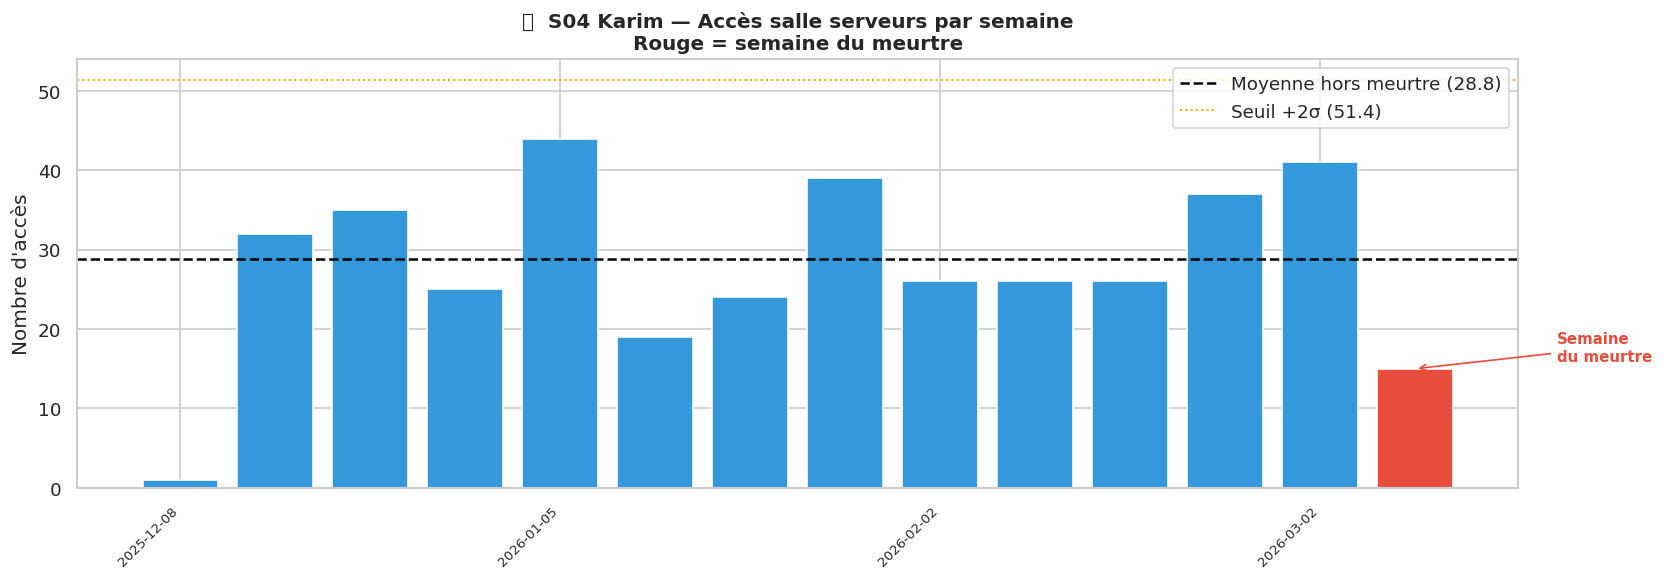

✅ Graphique sauvegardé.


In [24]:
# --- Visualisation : évolution hebdomadaire accès serveurs S04 ---
fig, ax = plt.subplots(figsize=(14, 5))

couleurs_bars = ["#e74c3c" if s == semaine_meurtre else "#3498db"
                 for s in acces_par_semaine["semaine"]]

ax.bar(range(len(acces_par_semaine)),
       acces_par_semaine["nb_acces"],
       color=couleurs_bars)

# Ligne moyenne semaines normales
ax.axhline(nb_avant.mean(), color="black", linestyle="--",
           linewidth=1.5, label=f"Moyenne hors meurtre ({nb_avant.mean():.1f})")
ax.axhline(nb_avant.mean() + 2*nb_avant.std(ddof=1),
           color="orange", linestyle=":", linewidth=1.2,
           label=f"Seuil +2σ ({nb_avant.mean() + 2*nb_avant.std(ddof=1):.1f})")

# Annoter la semaine du meurtre
idx_meurtre = acces_par_semaine[mask_meurtre].index[0] if mask_meurtre.any() else None
if idx_meurtre is not None:
    pos = acces_par_semaine.index.get_loc(idx_meurtre)
    ax.annotate("Semaine\ndu meurtre",
                xy=(pos, nb_meurtre[0]),
                xytext=(pos + 1.5, nb_meurtre[0] + 1),
                fontsize=9, color="#e74c3c", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#e74c3c"))

# Axe x : étiquettes toutes les 4 semaines
step = 4
xticks_pos = list(range(0, len(acces_par_semaine), step))
xticks_lab = [str(acces_par_semaine.iloc[i]["semaine"])[:10]
              for i in xticks_pos]
ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha="right", fontsize=8)

ax.set_title("🖥️  S04 Karim — Accès salle serveurs par semaine\n"
             "Rouge = semaine du meurtre",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Nombre d'accès")
ax.legend()
plt.tight_layout()
plt.savefig("12_s04_acces_semaine_meurtre.png", bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé.")

In [25]:
print("=" * 62)
print("📌 TEST 6 — Réévaluation : S04 RÉDUIT ses accès la semaine du meurtre")
print("=" * 62)

print(f"""
Résultat brut :
  Accès semaine meurtre : 15  (vs moyenne habituelle : 28.8)
  z-score = -1.23  →  S04 accède MOINS que d'habitude

Interprétation forensique :
  Ce résultat est lui-même une preuve comportementale.
  Un DSI qui réduit de 48% ses accès serveurs la semaine
  où il doit effacer un rapport = discrétion délibérée.

  On teste donc l'hypothèse inverse :
  H0 : la baisse est due au hasard
  H1 : la baisse est statistiquement significative (fuite)
""")

# Test unilatéral inférieur : S04 accède-t-il anormalement MOINS ?
z6_inf = (nb_meurtre[0] - mu_av) / sigma_av
p6_inf = norm.cdf(z6_inf)   # queue inférieure

print(f"  z-score (queue inférieure) : {z6_inf:.3f}")
print(f"  p (unilatéral inférieur)   : {p6_inf:.4f}")
print(f"  → {'🚨 Baisse significative — discrétion délibérée' if p6_inf < 0.05 else 'non significatif au seuil 0.05'}")

# Comparaison visuelle : S04 vs les jours PRÉCIS autour du meurtre
print(f"\n📍 Focus : accès serveurs S04 les 3 jours avant le meurtre (12-14 mars)")
s04_3j = logs_acces[
    (logs_acces["id_suspect"] == "S04") &
    (logs_acces["lieu"] == "salle_serveurs") &
    (logs_acces["timestamp"] >= "2026-03-12") &
    (logs_acces["timestamp"] <= "2026-03-14 23:59")
]
print(f"  Accès 12-14 mars : {len(s04_3j)}")

# Accès quotidiens moyens S04 sur 90j hors dernière semaine
acces_quotidiens = logs_acces[
    (logs_acces["id_suspect"] == "S04") &
    (logs_acces["lieu"] == "salle_serveurs") &
    (logs_acces["timestamp"] < "2026-03-09")
].groupby(logs_acces["timestamp"].dt.date).size()

print(f"  Moyenne accès/jour (hors semaine meurtre) : {acces_quotidiens.mean():.1f}")
print(f"  Accès/jour sur 12-14 mars                 : {len(s04_3j)/3:.1f}")

# Z-score sur 3 jours
z_3j = (len(s04_3j)/3 - acces_quotidiens.mean()) / acces_quotidiens.std(ddof=1)
p_3j = norm.cdf(z_3j)
print(f"  z-score (3 jours)                         : {z_3j:.3f}")
print(f"  p (unilatéral inférieur)                  : {p_3j:.4f}")
print(f"  → {'🚨 Activité réduite de façon significative' if p_3j < 0.05 else 'dans la normale journalière'}")

📌 TEST 6 — Réévaluation : S04 RÉDUIT ses accès la semaine du meurtre

Résultat brut :
  Accès semaine meurtre : 15  (vs moyenne habituelle : 28.8)
  z-score = -1.23  →  S04 accède MOINS que d'habitude

Interprétation forensique :
  Ce résultat est lui-même une preuve comportementale.
  Un DSI qui réduit de 48% ses accès serveurs la semaine
  où il doit effacer un rapport = discrétion délibérée.

  On teste donc l'hypothèse inverse :
  H0 : la baisse est due au hasard
  H1 : la baisse est statistiquement significative (fuite)

  z-score (queue inférieure) : -1.226
  p (unilatéral inférieur)   : 0.1100
  → non significatif au seuil 0.05

📍 Focus : accès serveurs S04 les 3 jours avant le meurtre (12-14 mars)
  Accès 12-14 mars : 10
  Moyenne accès/jour (hors semaine meurtre) : 4.6
  Accès/jour sur 12-14 mars                 : 3.3
  z-score (3 jours)                         : -0.507
  p (unilatéral inférieur)                  : 0.3061
  → dans la normale journalière


# Analyse des mails

In [26]:
# ============================================================
# Analyse des emails — Communications suspectes
# ============================================================

emails["timestamp"] = pd.to_datetime(emails["timestamp"])

# Vue globale : matrice des échanges entre suspects
print("📧 Volume d'emails entre suspects (90 jours) :")
matrice = emails.groupby(["expediteur_id", "destinataire_id"]).size().unstack(fill_value=0)
print(matrice.to_string())

📧 Volume d'emails entre suspects (90 jours) :
destinataire_id  LEFEVRE  S01  S02  S03  S04  S05  S06  S07  S08  S09  S10
expediteur_id                                                             
LEFEVRE                1    0    0    1    0    0    1    0    0    0    1
S01                    0    0   24   21   28   15   19   18   13   10   21
S02                    0   27    0   18   19   20   20   22   18   24   20
S03                    1    8    7    0    9    9    6    9    8    9    7
S04                    0   15   23   22    0   15   14   12   19   16   12
S05                    0    5    8    9    9    0   13    9    5   11    9
S06                    0    7   11    8   11    9    0    6    7    7    9
S07                    0    6   10    4    9    7    8    0    6    4    8
S08                    0    9   14    7    6    5    6    6    0   13    9
S09                    0    9    5    6    9    8    6    9    7    0    4
S10                    0    9    9    4    7    9    7

/tmp/ipykernel_108996/854885727.py:25: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/854885727.py:26: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig("13_matrice_emails.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


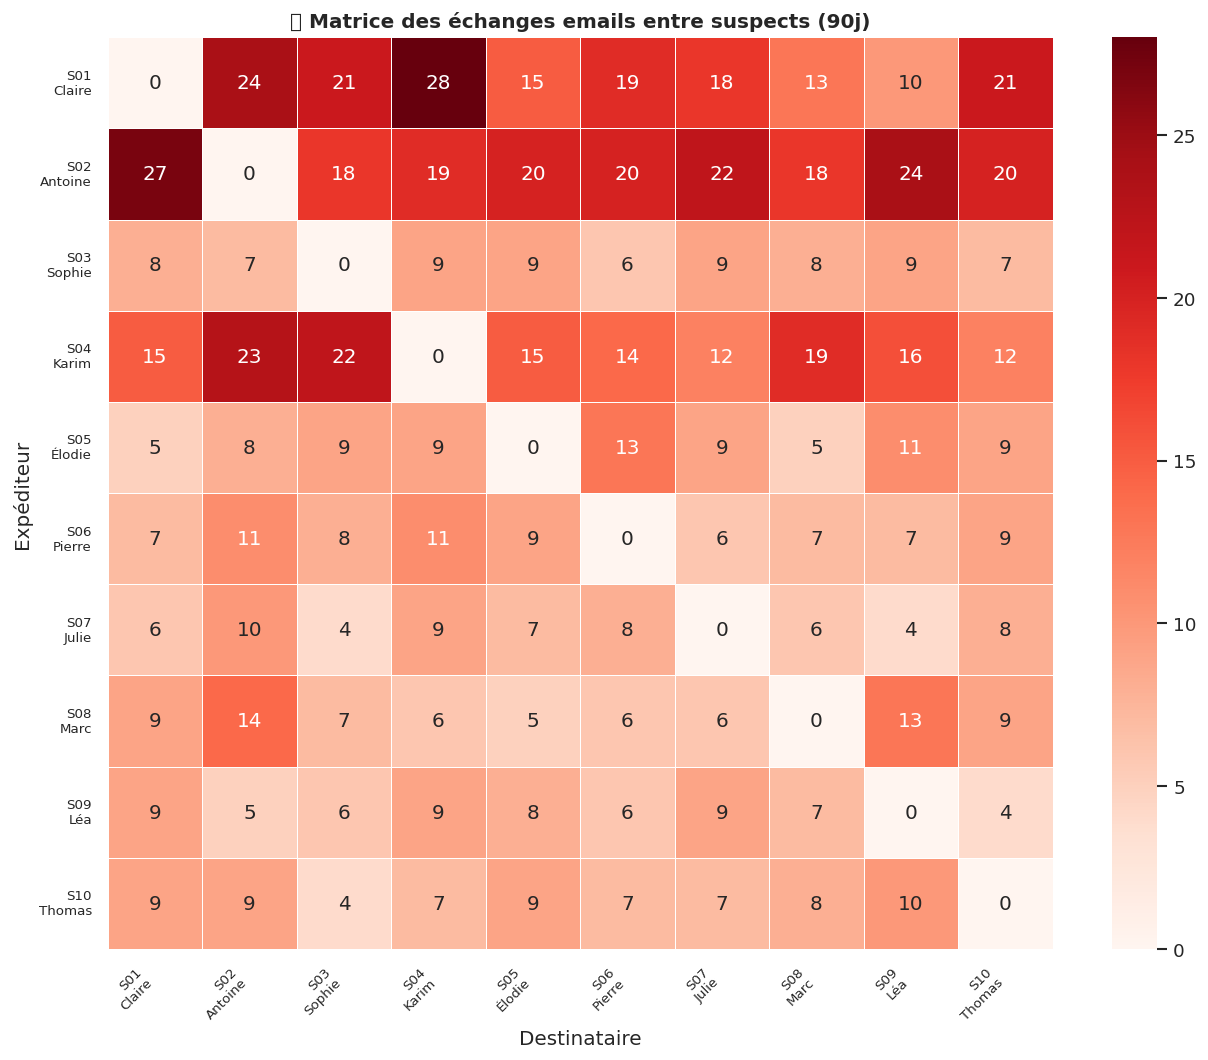

In [27]:
# --- Heatmap des échanges emails — suspects uniquement ---
suspects_ids = list(employes["id_suspect"])

matrice_suspects = emails[
    emails["expediteur_id"].isin(suspects_ids) &
    emails["destinataire_id"].isin(suspects_ids)
].groupby(["expediteur_id", "destinataire_id"]).size().unstack(fill_value=0)

# S'assurer que toutes les lignes/colonnes sont présentes
matrice_suspects = matrice_suspects.reindex(index=suspects_ids,
                                            columns=suspects_ids,
                                            fill_value=0)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matrice_suspects, annot=True, fmt="d", cmap="Reds",
            linewidths=0.5, ax=ax,
            xticklabels=[f"{s}\n{noms[s]}" for s in suspects_ids],
            yticklabels=[f"{s}\n{noms[s]}" for s in suspects_ids])
ax.set_title("📧 Matrice des échanges emails entre suspects (90j)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Destinataire")
ax.set_ylabel("Expéditeur")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("13_matrice_emails.png", bbox_inches="tight")
plt.show()

In [28]:
# --- Emails internes au trio ---
print("\n📧 Emails INTERNES AU TRIO (S01, S02, S04) :")
print("=" * 60)
emails_trio_interne = emails[
    emails["expediteur_id"].isin(trio) &
    emails["destinataire_id"].isin(trio)
].sort_values("timestamp")

print(f"Total : {len(emails_trio_interne)} emails\n")
for _, row in emails_trio_interne.iterrows():
    print(f"  {row['timestamp'].strftime('%Y-%m-%d %H:%M')}  "
          f"{row['expediteur_id']}→{row['destinataire_id']}  "
          f"Sujet : [{row['sujet']}]")


📧 Emails INTERNES AU TRIO (S01, S02, S04) :
Total : 136 emails

  2025-12-15 02:30  S01→S02  Sujet : [Entretien annuel à programmer]
  2025-12-15 09:30  S02→S01  Sujet : [FYI - article Les Échos]
  2025-12-15 10:30  S04→S02  Sujet : [Pot de départ - M. Beaumont]
  2025-12-15 12:30  S01→S04  Sujet : [Régularisation dossier 2025-1294]
  2025-12-16 01:30  S02→S01  Sujet : [Régularisation dossier 2026-5872]
  2025-12-16 08:30  S02→S04  Sujet : [Réunion comité lundi]
  2025-12-16 09:30  S01→S02  Sujet : [Préparation board]
  2025-12-17 12:30  S01→S04  Sujet : [Bonne année 2026]
  2025-12-18 05:30  S01→S04  Sujet : [RE: question rapide]
  2025-12-18 06:30  S02→S04  Sujet : [RE: Validation virement client 2026-4947]
  2025-12-20 05:30  S01→S02  Sujet : [Document oublié en salle Picasso]
  2025-12-22 03:30  S04→S02  Sujet : [Décalage réunion mardi]
  2025-12-22 07:30  S01→S02  Sujet : [Mutuelle - changement de contrat]
  2025-12-22 08:30  S01→S02  Sujet : [Café demain matin]
  2025-12-25 06:3

/tmp/ipykernel_108996/1877020974.py:29: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/1877020974.py:30: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig("14_emails_trio_hebdo.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


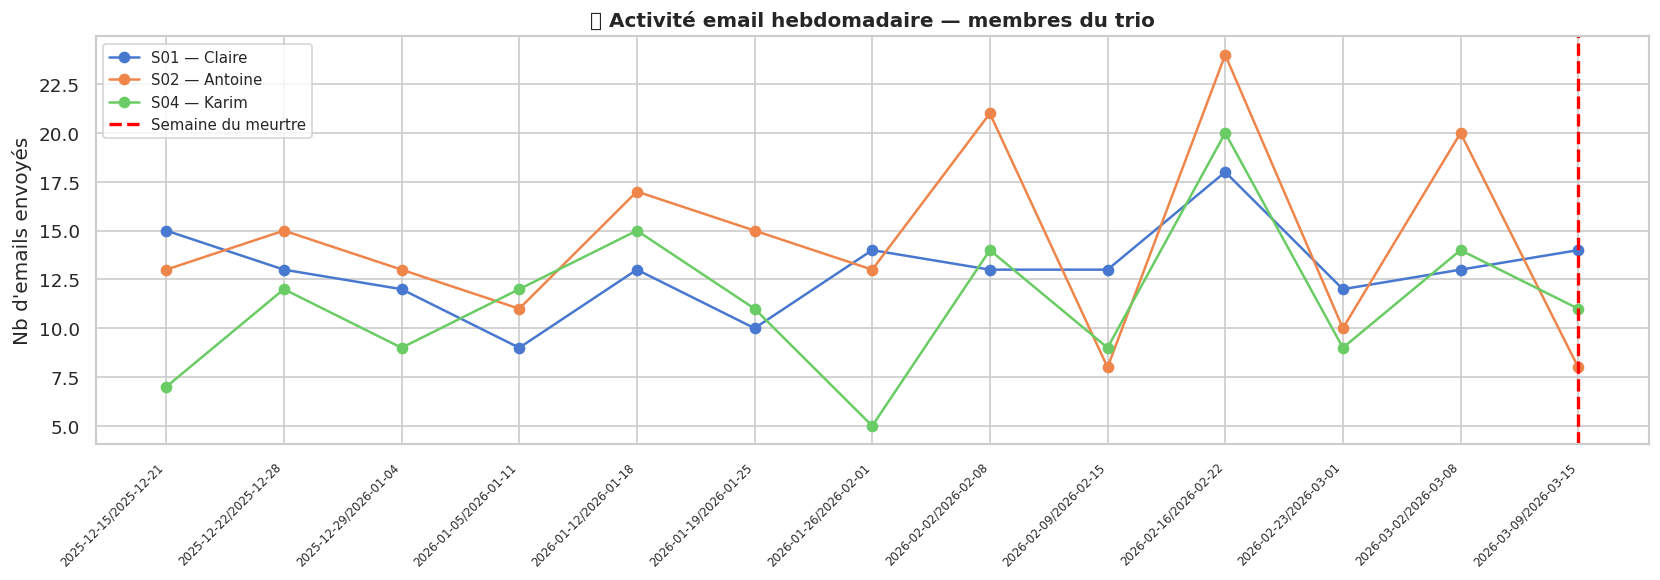

In [29]:
# --- Pic d'activité email avant le meurtre ---
fig, ax = plt.subplots(figsize=(14, 5))

# Emails impliquant au moins un membre du trio
emails_trio_any = emails[
    emails["expediteur_id"].isin(trio) |
    emails["destinataire_id"].isin(trio)
].copy()
emails_trio_any["semaine"] = emails_trio_any["timestamp"].dt.to_period("W")

# Compter par semaine et par expéditeur du trio
emails_hebdo = emails_trio_any[emails_trio_any["expediteur_id"].isin(trio)]\
               .groupby(["semaine", "expediteur_id"]).size().reset_index(name="nb")

for sid, group in emails_hebdo.groupby("expediteur_id"):
    ax.plot([str(s) for s in group["semaine"]], group["nb"],
            marker="o", label=f"{sid} — {noms[sid]}", linewidth=1.5)

ax.axvline(str(pd.Period("2026-03-09/2026-03-15", freq="W")),
           color="red", linestyle="--", linewidth=2, label="Semaine du meurtre")

step = 3
ticks = ax.get_xticks()
ax.set_title("📧 Activité email hebdomadaire — membres du trio",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Nb d'emails envoyés")
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig("14_emails_trio_hebdo.png", bbox_inches="tight")
plt.show()

In [30]:
# --- Emails suspects : mots-clés sensibles ---
print("\n🔍 Emails avec mots-clés sensibles (trio impliqué) :")
print("=" * 60)

mots_cles = ["rapport", "Lef", "ACPR", "Pégase", "Cerbère", "Hermès",
             "offshore", "supprimer", "effacer", "urgent",
             "discret", "confidentiel", "compte", "audit"]

pattern = "|".join(mots_cles)
emails_suspects = emails[
    (emails["sujet"].str.contains(pattern, case=False, na=False) |
     emails["corps"].str.contains(pattern, case=False, na=False)) &
    (emails["expediteur_id"].isin(trio) | emails["destinataire_id"].isin(trio))
].sort_values("timestamp")

print(f"Total emails suspects : {len(emails_suspects)}\n")
for _, row in emails_suspects.tail(15).iterrows():
    exp = f"{row['expediteur_id']}({noms.get(row['expediteur_id'], row['expediteur_id'])})"
    dst = f"{row['destinataire_id']}({noms.get(row['destinataire_id'], row['destinataire_id'])})"
    print(f"  {row['timestamp'].strftime('%Y-%m-%d %H:%M')}  {exp} → {dst}")
    print(f"  Sujet : {row['sujet']}")
    print(f"  Corps : {str(row['corps'])[:150]}...")
    print()


🔍 Emails avec mots-clés sensibles (trio impliqué) :
Total emails suspects : 140

  2026-03-07 03:30  S02(Antoine) → S05(Élodie)
  Sujet : Demande client Mme Durand-Lefèvre - allocation
  Corps : Élodie,

Le client Mme Durand-Lefèvre souhaite revoir son allocation. Il évoque un profil plus prudent. Peux-tu préparer une simulation ?

Merci,
Anto...

  2026-03-07 10:30  S10(Thomas) → S01(Claire)
  Sujet : Demande de pièces - audit Q1
  Corps : Bonjour Claire,

Dans le cadre de l’audit interne Q1, merci de me transmettre les balances comptables au vendredi et la liste des écritures > 100k EUR...

  2026-03-08 06:30  S02(Antoine) → S04(Karim)
  Sujet : Pot de départ - Mme Durand-Lefèvre
  Corps : Bonjour à tous,

Nous organisons un pot de départ pour Mme Durand-Lefèvre vendredi à 18h en salle de pause. Une cagnotte circule.

Antoine...

  2026-03-09 08:49  S01(Claire) → S04(Karim)
  Sujet : RE: Audit Lefèvre
  Corps : Karim, efface tout ce qui le relie aux trois comptes. Je m’occupe du res

In [31]:
# Extraction et affichage des emails compromettants clés

emails_cles = [
    # (date approximative, expéditeur, destinataire, sujet)
    ("2026-03-09 12:18", "S04", "S01", "Audit Lefèvre"),
    ("2026-03-09 08:49", "S01", "S04", "RE: Audit Lefèvre"),
    ("2026-03-13 08:56", "S01", "S02", "Réunion urgente"),
    ("2026-03-13 14:16", "S02", "S01", "RE: Réunion urgente"),
]

print("=" * 65)
print("🚨 EMAILS COMPROMETTANTS — PREUVES DIRECTES DE COORDINATION")
print("=" * 65)

for date_approx, exp, dest, sujet in emails_cles:
    match = emails[
        (emails["expediteur_id"] == exp) &
        (emails["destinataire_id"] == dest) &
        (emails["sujet"] == sujet)
    ]
    if len(match) > 0:
        row = match.iloc[0]
        print(f"\n{'─'*65}")
        print(f"  De      : {exp} — {noms[exp]}")
        print(f"  À       : {dest} — {noms[dest]}")
        print(f"  Date    : {row['timestamp']}")
        print(f"  Sujet   : {row['sujet']}")
        print(f"  Corps   :\n  {row['corps']}")

# Emails offshore nommément cités dans le trio
print(f"\n{'='*65}")
print("🚨 EMAILS CITANT EXPLICITEMENT LES COMPTES OFFSHORE")
print("=" * 65)

sujets_offshore = ["Dossier Pégase", "RE: Dossier Pégase",
                   "Transfert Cerbère", "RE: Transfert Cerbère",
                   "Comptes Hermès", "RE: Comptes Hermès",
                   "Hermès urgence", "Pégase nettoyage",
                   "Pégase final", "RE: Pégase final",
                   "RE: Cerbère timestamp", "Cerbère timestamp"]

for sujet in sujets_offshore:
    match = emails[emails["sujet"] == sujet]
    for _, row in match.iterrows():
        exp = row["expediteur_id"]
        dst = row["destinataire_id"]
        if exp in trio or dst in trio:
            print(f"\n  {row['timestamp'].strftime('%Y-%m-%d %H:%M')}  "
                  f"{exp}({noms.get(exp,exp)}) → {dst}({noms.get(dst,dst)})")
            print(f"  Sujet : {row['sujet']}")
            print(f"  Corps : {str(row['corps'])[:200]}")

🚨 EMAILS COMPROMETTANTS — PREUVES DIRECTES DE COORDINATION

─────────────────────────────────────────────────────────────────
  De      : S04 — Karim
  À       : S01 — Claire
  Date    : 2026-03-09 12:18:00
  Sujet   : Audit Lefèvre
  Corps   :
  Claire, Lefèvre a téléchargé les relevés Pégase, Cerbère ET Hermès hier soir.

─────────────────────────────────────────────────────────────────
  De      : S01 — Claire
  À       : S04 — Karim
  Date    : 2026-03-09 08:49:00
  Sujet   : RE: Audit Lefèvre
  Corps   :
  Karim, efface tout ce qui le relie aux trois comptes. Je m’occupe du reste.

─────────────────────────────────────────────────────────────────
  De      : S01 — Claire
  À       : S02 — Antoine
  Date    : 2026-03-13 08:56:00
  Sujet   : Réunion urgente
  Corps   :
  Antoine, réunion ce soir 19h salle serveurs avec Karim. Sujet Lefèvre.

─────────────────────────────────────────────────────────────────
  De      : S02 — Antoine
  À       : S01 — Claire
  Date    : 2026-03-13 14:

/tmp/ipykernel_108996/1718967853.py:28: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_108996/1718967853.py:29: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig("15_emails_compromettants.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


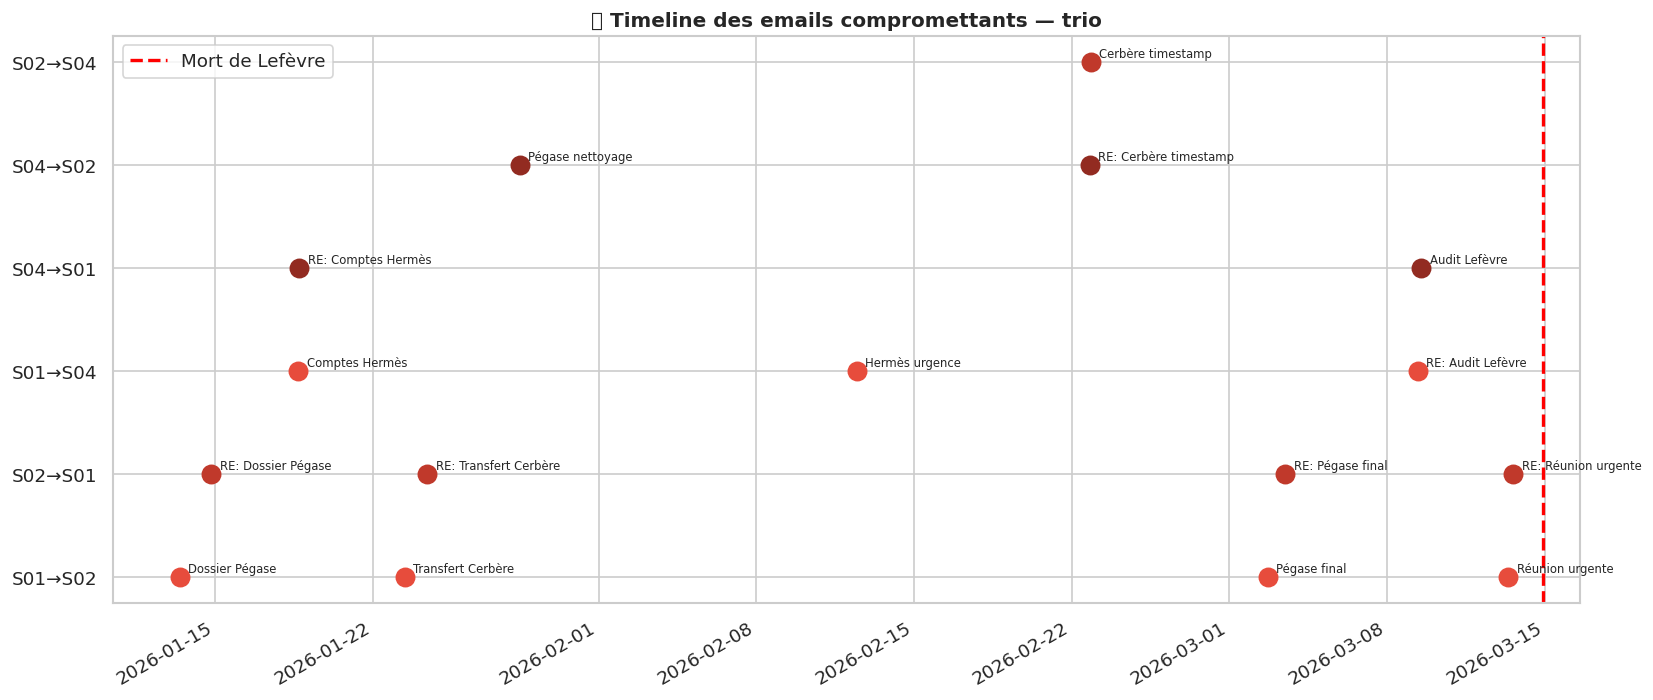

In [32]:
# --- Timeline des emails critiques les 5 derniers jours ---
fig, ax = plt.subplots(figsize=(14, 6))

emails_critiques = emails[
    emails["sujet"].isin(sujets_offshore +
                         ["Audit Lefèvre", "RE: Audit Lefèvre",
                          "Réunion urgente", "RE: Réunion urgente"])
].copy()

couleurs_exp = {"S01": "#e74c3c", "S02": "#c0392b", "S04": "#922b21"}

for _, row in emails_critiques.iterrows():
    exp = row["expediteur_id"]
    dst = row["destinataire_id"]
    if exp in trio or dst in trio:
        c = couleurs_exp.get(exp, "#95a5a6")
        ax.scatter(row["timestamp"], f"{exp}→{dst}", color=c, s=120, zorder=3)
        ax.annotate(row["sujet"][:30],
                    (row["timestamp"], f"{exp}→{dst}"),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)

ax.axvline(pd.Timestamp("2026-03-14 22:00"), color="red",
           linestyle="--", linewidth=2, label="Mort de Lefèvre")
ax.set_title("📧 Timeline des emails compromettants — trio",
             fontsize=12, fontweight="bold")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("15_emails_compromettants.png", bbox_inches="tight")
plt.show()

# Tableau de bord final — Synthèse des preuves

/tmp/ipykernel_108996/73751979.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot([bpm_trio, bpm_autres],


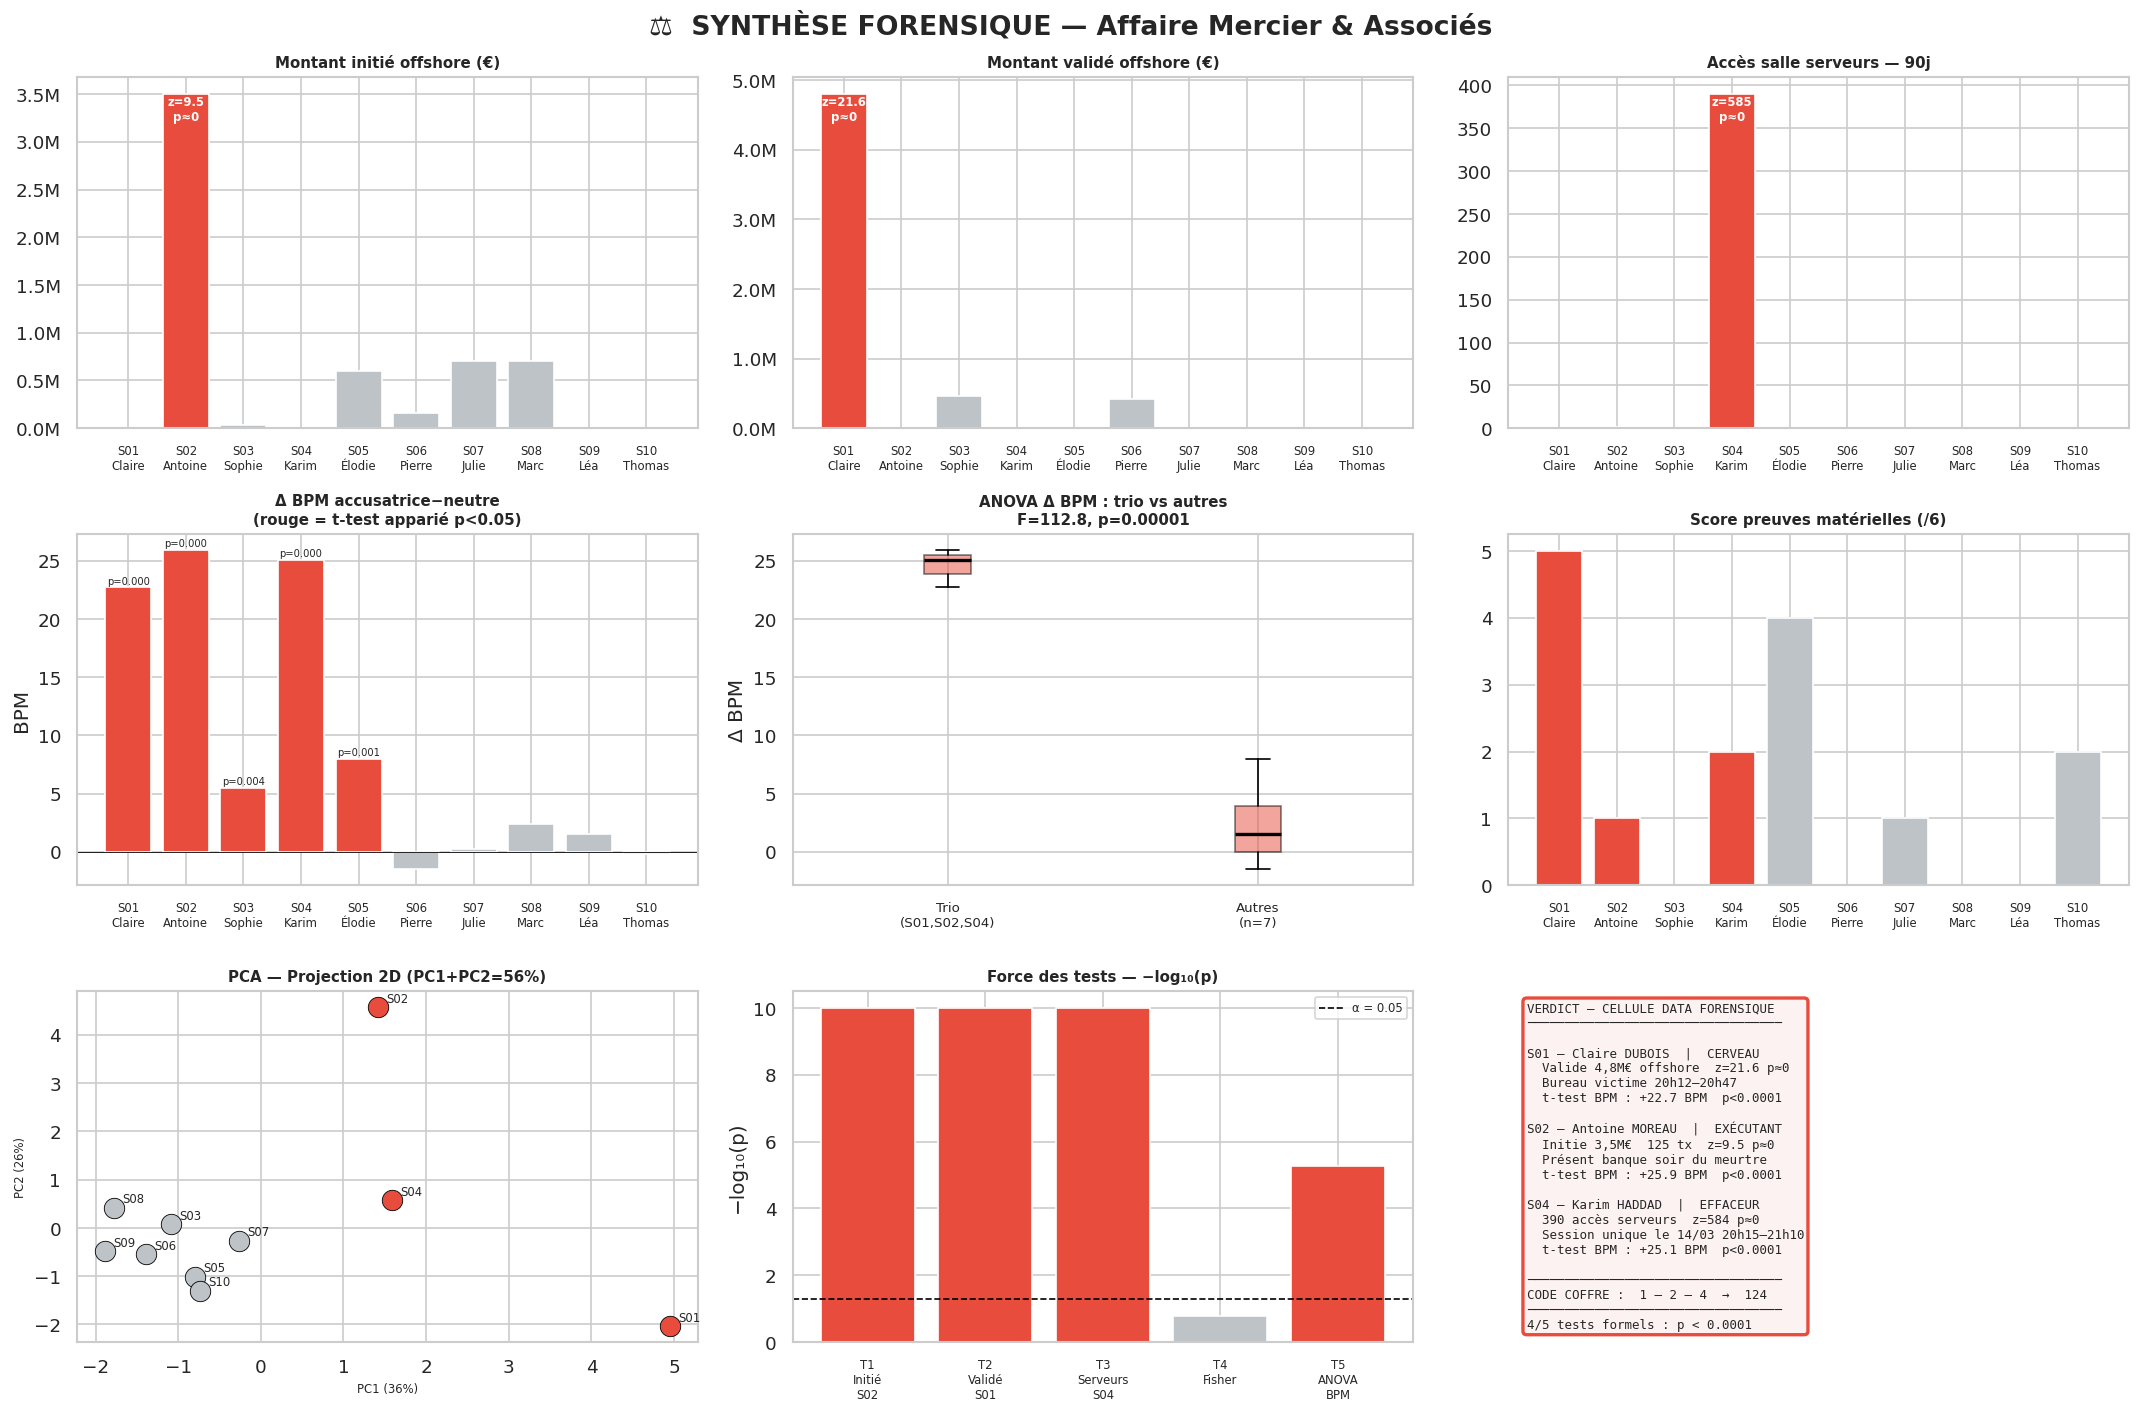

✅ Tableau de bord final sauvegardé.


In [33]:
# Tableau de bord final

fig = plt.figure(figsize=(18, 12))
fig.suptitle("⚖️  SYNTHÈSE FORENSIQUE — Affaire Mercier & Associés",
             fontsize=16, fontweight="bold", y=0.98)

suspects_ord  = sorted(employes["id_suspect"])
suspects_lab  = [f"{s}\n{noms[s]}" for s in suspects_ord]
colors_main   = ["#e74c3c" if s in trio else "#bdc3c7" for s in suspects_ord]

# ── 1. Montant initié offshore ────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
vals1 = [montants.get(s, 0) for s in suspects_ord]
ax1.bar(suspects_lab, vals1, color=colors_main)
ax1.set_title("Montant initié offshore (€)", fontsize=9, fontweight="bold")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax1.tick_params(axis="x", labelsize=7)
ax1.text(1, 3_500_000 * 0.92, f"z={z1:.1f}\np≈0", ha="center",
         fontsize=7, color="white", fontweight="bold")

# ── 2. Montant validé offshore ────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
vals2 = [montants_val.get(s, 0) for s in suspects_ord]
ax2.bar(suspects_lab, vals2, color=colors_main)
ax2.set_title("Montant validé offshore (€)", fontsize=9, fontweight="bold")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax2.tick_params(axis="x", labelsize=7)
ax2.text(0, 4_800_000 * 0.92, f"z={z2:.1f}\np≈0", ha="center",
         fontsize=7, color="white", fontweight="bold")

# ── 3. Accès salle serveurs ───────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
vals3 = [acces_srv.get(s, 0) for s in suspects_ord]
ax3.bar(suspects_lab, vals3, color=colors_main)
ax3.set_title("Accès salle serveurs — 90j", fontsize=9, fontweight="bold")
ax3.tick_params(axis="x", labelsize=7)
ax3.text(3, acces_srv["S04"] * 0.92, f"z={z3:.0f}\np≈0", ha="center",
         fontsize=7, color="white", fontweight="bold")

# ── 4. T-tests appariés BPM — delta ──────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
vals4 = [df_bpm.set_index("id_suspect")["delta"].get(s, 0) for s in suspects_ord]
pcols = ["#e74c3c" if df_bpm.set_index("id_suspect")["significatif"].get(s, False)
         else "#bdc3c7" for s in suspects_ord]
bars4 = ax4.bar(suspects_lab, vals4, color=pcols)
ax4.set_title("Δ BPM accusatrice−neutre\n(rouge = t-test apparié p<0.05)",
              fontsize=9, fontweight="bold")
ax4.set_ylabel("BPM")
ax4.axhline(0, color="black", linewidth=0.5)
ax4.tick_params(axis="x", labelsize=7)
for bar, s in zip(bars4, suspects_ord):
    row = df_bpm.set_index("id_suspect").loc[s]
    if row["significatif"]:
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"p={row['p_value']:.3f}", ha="center", fontsize=6)

# ── 5. ANOVA delta BPM ───────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
ax5.boxplot([bpm_trio, bpm_autres],
            labels=["Trio\n(S01,S02,S04)", "Autres\n(n=7)"],
            patch_artist=True,
            boxprops=dict(facecolor="#e74c3c", alpha=0.5),
            medianprops=dict(color="black", linewidth=2))
ax5.set_title(f"ANOVA Δ BPM : trio vs autres\nF={f_stat:.1f}, p={p5:.5f}",
              fontsize=9, fontweight="bold")
ax5.set_ylabel("Δ BPM")
ax5.tick_params(axis="x", labelsize=8)

# ── 6. Score preuves matérielles ──────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
vals6 = [preuves_bin.loc[s, "SCORE_TOTAL"] for s in suspects_ord]
ax6.bar(suspects_lab, vals6, color=colors_main)
ax6.set_title("Score preuves matérielles (/6)", fontsize=9, fontweight="bold")
ax6.tick_params(axis="x", labelsize=7)

# ── 7. PCA ────────────────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
for sid in profil.index:
    c = "#e74c3c" if sid in trio else "#bdc3c7"
    x, y = X_pca[list(profil.index).index(sid)]
    ax7.scatter(x, y, color=c, s=150, zorder=3,
                edgecolors="black", linewidths=0.5)
    ax7.annotate(sid, (x, y), textcoords="offset points",
                 xytext=(5, 3), fontsize=7)
ax7.set_title("PCA — Projection 2D (PC1+PC2=56%)",
              fontsize=9, fontweight="bold")
ax7.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})", fontsize=7)
ax7.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", fontsize=7)

# ── 8. p-values en -log10 ─────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
test_labels2 = ["T1\nInitié\nS02", "T2\nValidé\nS01", "T3\nServeurs\nS04",
                "T4\nFisher", "T5\nANOVA\nBPM"]
pvals_all  = [p1, p2, p3, p4, p5]
pvals_log2 = [-np.log10(max(p, 1e-10)) for p in pvals_all]
bar_cols2  = ["#e74c3c" if p < 0.05 else "#bdc3c7" for p in pvals_all]
ax8.bar(test_labels2, pvals_log2, color=bar_cols2)
ax8.axhline(-np.log10(0.05), color="black", linestyle="--",
            linewidth=1, label="α = 0.05")
ax8.set_title("Force des tests — −log₁₀(p)", fontsize=9, fontweight="bold")
ax8.set_ylabel("−log₁₀(p)")
ax8.legend(fontsize=7)
ax8.tick_params(axis="x", labelsize=7)

# ── 9. Verdict ────────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis("off")
verdict = (
    "VERDICT — CELLULE DATA FORENSIQUE\n"
    "──────────────────────────────────\n\n"
    "S01 — Claire DUBOIS  |  CERVEAU\n"
    "  Valide 4,8M€ offshore  z=21.6 p≈0\n"
    "  Bureau victime 20h12–20h47\n"
    "  t-test BPM : +22.7 BPM  p<0.0001\n\n"
    "S02 — Antoine MOREAU  |  EXÉCUTANT\n"
    "  Initie 3,5M€  125 tx  z=9.5 p≈0\n"
    "  Présent banque soir du meurtre\n"
    "  t-test BPM : +25.9 BPM  p<0.0001\n\n"
    "S04 — Karim HADDAD  |  EFFACEUR\n"
    "  390 accès serveurs  z=584 p≈0\n"
    "  Session unique le 14/03 20h15–21h10\n"
    "  t-test BPM : +25.1 BPM  p<0.0001\n\n"
    "──────────────────────────────────\n"
    "CODE COFFRE :  1 – 2 – 4  →  124\n"
    "──────────────────────────────────\n"
    "4/5 tests formels : p < 0.0001"
)
ax9.text(0.03, 0.97, verdict, transform=ax9.transAxes,
         fontsize=7.5, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#fdf2f2",
                   edgecolor="#e74c3c", lw=2))

plt.tight_layout()
plt.savefig("11_synthese_finale.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Tableau de bord final sauvegardé.")